# Cross-Asset Strategy Family Comparison

Revised per comments: this notebook only uses data from `2020-01-01` onward and runs each asset group as an isolated universe. There is no combined cross-group portfolio and no cross-group factor. Energy is shown in coverage but skipped because `CL` has no same-group peer in the available data.

In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (13, 6),
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)
%matplotlib inline
%config InlineBackend.figure_format = "retina"

ROOT_GROUPS = {
    "6A": "Currencies",
    "6B": "Currencies",
    "6C": "Currencies",
    "6E": "Currencies",
    "6J": "Currencies",
    "ES": "Equities",
    "NQ": "Equities",
    "CL": "Energy",
    "GC": "Metals",
    "SI": "Metals",
    "HG": "Metals",
    "PL": "Metals",
    "PA": "Metals",
    "ALI": "Metals",
    "ZT": "Fixed income",
    "ZF": "Fixed income",
    "ZN": "Fixed income",
    "ZB": "Fixed income",
}
GROUP_ORDER = ["Currencies", "Equities", "Energy", "Fixed income", "Metals"]
DATA_DIR = Path("/home/famadeo/research/databento-asset-browser/data/futures_continuous")
START_TS = pd.Timestamp("2020-01-01")

STRATEGY_LABELS = {
    "core_lead_lag": "#1 Core lead/lag",
    "core_lead_lag_entropy_kl": "#4 Core lead/lag + entropy/KL",
    "pair_mr": "#3 Pair residual MR",
    "pair_mr_entropy_kl": "#4 Pair MR + entropy/KL",
    "liquidity_catchup": "#5 Liquidity catch-up",
}
STRATEGY_ORDER = [
    "core_lead_lag",
    "core_lead_lag_entropy_kl",
    "pair_mr",
    "pair_mr_entropy_kl",
    "liquidity_catchup",
]
STRATEGY_COLORS = {
    "core_lead_lag": "tab:blue",
    "core_lead_lag_entropy_kl": "tab:cyan",
    "pair_mr": "tab:green",
    "pair_mr_entropy_kl": "tab:orange",
    "liquidity_catchup": "tab:purple",
}

VOL_LOOKBACK_DAYS = 63
BETA_LOOKBACK_DAYS = 126
LEAD_LAG_DAYS = 5
MAX_PAIR_HOLD_DAYS = 20
MAX_CORE_HOLD_DAYS = 10
MAX_VOL_SCALE = 5.0
COST_BPS_PER_TURNOVER = 1.5
DISTRIBUTION_BINS = 30
BARS_PER_YEAR = 252.0

print(f"data: {DATA_DIR}")
print(f"start: {START_TS.date()}")

data: /home/famadeo/research/databento-asset-browser/data/futures_continuous
start: 2020-01-01


## Data And Shared Helpers

Each group builds its own common timestamp panel, volatility scaling, beta-hedged residuals, pair list, peer factor, liquidity filters, and strategy portfolio. This intentionally avoids aligning all groups to one global panel.

In [2]:
def load_root(root: str) -> pd.DataFrame:
    frame = pd.read_csv(DATA_DIR / f"{root}.csv", parse_dates=["date"])
    frame["date"] = pd.to_datetime(frame["date"], utc=True).dt.tz_convert(None).dt.normalize()
    frame = frame.drop_duplicates("date", keep="last").sort_values("date").set_index("date")
    return frame[["cont_logprice", "cont_logret", "volume"]].rename(
        columns={
            "cont_logprice": root,
            "cont_logret": f"{root}_ret",
            "volume": f"{root}_volume",
        }
    )


loaded = {root: load_root(root) for root in ROOT_GROUPS}


def roots_for_group(group: str) -> list[str]:
    return [root for root, root_group in ROOT_GROUPS.items() if root_group == group]


def build_group_panel(
    group: str,
) -> tuple[list[str], pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    roots = roots_for_group(group)
    price_panel = pd.concat(
        [loaded[root][[root]] for root in roots], axis=1, join="inner"
    ).sort_index()
    return_panel = pd.concat(
        [loaded[root][[f"{root}_ret"]] for root in roots], axis=1, join="inner"
    ).sort_index()
    volume_panel = pd.concat(
        [loaded[root][[f"{root}_volume"]] for root in roots], axis=1, join="inner"
    ).sort_index()
    return_panel.columns = roots

    price_panel = price_panel.loc[price_panel.index >= START_TS]
    return_panel = return_panel.reindex(price_panel.index)
    volume_panel = volume_panel.reindex(price_panel.index).fillna(0.0)

    returns = price_panel.diff().fillna(return_panel).dropna(how="all")
    price_panel = price_panel.reindex(returns.index)
    volume_panel = volume_panel.reindex(returns.index).fillna(0.0)

    rolling_vol = (
        returns.rolling(VOL_LOOKBACK_DAYS, min_periods=VOL_LOOKBACK_DAYS // 2).std().shift(1)
    )
    rolling_vol = rolling_vol.clip(lower=rolling_vol.quantile(0.05), axis=1)
    target_bar_vol = float(rolling_vol.stack().median()) if len(rolling_vol.stack()) else np.nan
    vol_adjusted_returns = (
        returns * (target_bar_vol / rolling_vol).clip(upper=MAX_VOL_SCALE)
    ).dropna(how="all")
    return (
        roots,
        price_panel.reindex(vol_adjusted_returns.index),
        returns.reindex(vol_adjusted_returns.index),
        vol_adjusted_returns,
        volume_panel.reindex(vol_adjusted_returns.index).fillna(0.0),
    )


def robust_zscore(series: pd.Series, lookback: int = BETA_LOOKBACK_DAYS) -> pd.Series:
    median = series.rolling(lookback, min_periods=lookback // 2).median().shift(1)
    q25 = series.rolling(lookback, min_periods=lookback // 2).quantile(0.25).shift(1)
    q75 = series.rolling(lookback, min_periods=lookback // 2).quantile(0.75).shift(1)
    sigma = ((q75 - q25) / 1.349).replace(0.0, np.nan)
    return ((series - median) / sigma).replace([np.inf, -np.inf], np.nan)


def state_machine(
    index: pd.DatetimeIndex,
    enter_long: pd.Series,
    enter_short: pd.Series,
    exit_long: pd.Series,
    exit_short: pd.Series,
    max_hold: int,
) -> pd.Series:
    desired = np.zeros(len(index), dtype=float)
    state = 0
    holding_bars = 0
    enter_long_values = enter_long.fillna(False).to_numpy(dtype=bool)
    enter_short_values = enter_short.fillna(False).to_numpy(dtype=bool)
    exit_long_values = exit_long.fillna(False).to_numpy(dtype=bool)
    exit_short_values = exit_short.fillna(False).to_numpy(dtype=bool)
    for idx in range(len(index)):
        if state != 0:
            holding_bars += 1
        if (state == 1 and (exit_long_values[idx] or holding_bars >= max_hold)) or (
            state == -1 and (exit_short_values[idx] or holding_bars >= max_hold)
        ):
            state = 0
            holding_bars = 0
        if state == 0:
            if enter_long_values[idx]:
                state = 1
                holding_bars = 0
            elif enter_short_values[idx]:
                state = -1
                holding_bars = 0
        desired[idx] = state
    return pd.Series(desired, index=index).shift(1).fillna(0.0)


def calibration_edges(values: np.ndarray, bins: int) -> np.ndarray:
    values = values[np.isfinite(values)]
    if len(values) < 10:
        return np.array([-np.inf, np.inf])
    calibration_count = min(len(values), max(BETA_LOOKBACK_DAYS * 2, int(len(values) * 0.20)))
    calibration_values = values[:calibration_count]
    edges = np.quantile(calibration_values, np.linspace(0.0, 1.0, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 5:
        lo, hi = float(np.nanmin(calibration_values)), float(np.nanmax(calibration_values))
        if lo == hi:
            lo, hi = lo - 1e-9, hi + 1e-9
        edges = np.linspace(lo, hi, bins + 1)
    edges[0] = -np.inf
    edges[-1] = np.inf
    return edges


def rolling_entropy(series: pd.Series) -> pd.Series:
    values = series.fillna(0.0).to_numpy(dtype=float)
    edges = calibration_edges(values, DISTRIBUTION_BINS)
    n_bins = len(edges) - 1
    bin_idx = np.searchsorted(edges, values, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    one_hot = np.zeros((len(values), n_bins), dtype=float)
    one_hot[np.arange(len(values)), bin_idx] = 1.0
    cumulative = np.vstack([np.zeros((1, n_bins)), np.cumsum(one_hot, axis=0)])
    entropy = np.full(len(values), np.nan, dtype=float)
    for idx in range(BETA_LOOKBACK_DAYS // 2 - 1, len(values)):
        start_idx = max(0, idx - BETA_LOOKBACK_DAYS + 1)
        counts = cumulative[idx + 1] - cumulative[start_idx]
        probabilities = (counts + 0.5) / (counts.sum() + 0.5 * n_bins)
        entropy[idx] = -float(np.sum(probabilities * np.log(probabilities))) / np.log(n_bins)
    return pd.Series(entropy, index=series.index).shift(1)


def rolling_js(left: pd.Series, right: pd.Series) -> pd.Series:
    left = left.fillna(0.0)
    right = right.reindex(left.index).fillna(0.0)
    edges = calibration_edges(
        np.r_[left.to_numpy(dtype=float), right.to_numpy(dtype=float)], DISTRIBUTION_BINS
    )
    n_bins = len(edges) - 1

    def cumulative_counts(series: pd.Series) -> np.ndarray:
        values = series.to_numpy(dtype=float)
        bin_idx = np.searchsorted(edges, values, side="right") - 1
        bin_idx = np.clip(bin_idx, 0, n_bins - 1)
        one_hot = np.zeros((len(values), n_bins), dtype=float)
        one_hot[np.arange(len(values)), bin_idx] = 1.0
        return np.vstack([np.zeros((1, n_bins)), np.cumsum(one_hot, axis=0)])

    left_counts = cumulative_counts(left)
    right_counts = cumulative_counts(right)
    js_values = np.full(len(left), np.nan, dtype=float)
    for idx in range(BETA_LOOKBACK_DAYS // 2 - 1, len(left)):
        start_idx = max(0, idx - BETA_LOOKBACK_DAYS + 1)
        p = left_counts[idx + 1] - left_counts[start_idx] + 0.5
        q = right_counts[idx + 1] - right_counts[start_idx] + 0.5
        p = p / p.sum()
        q = q / q.sum()
        midpoint = 0.5 * (p + q)
        js_values[idx] = 0.5 * np.sum(p * np.log(p / midpoint)) + 0.5 * np.sum(
            q * np.log(q / midpoint)
        )
    return pd.Series(js_values, index=left.index).shift(1)


def entropy_kl_filter(
    entropy_series: pd.Series, js_left: pd.Series | None = None, js_right: pd.Series | None = None
) -> pd.Series:
    entropy = rolling_entropy(entropy_series)
    entropy_floor = (
        entropy.rolling(BETA_LOOKBACK_DAYS * 2, min_periods=BETA_LOOKBACK_DAYS)
        .quantile(0.25)
        .shift(1)
    )
    allowed = entropy >= entropy_floor
    if js_left is not None and js_right is not None:
        js = rolling_js(
            js_left.reindex(entropy_series.index), js_right.reindex(entropy_series.index)
        )
        js_ceiling = (
            js.rolling(BETA_LOOKBACK_DAYS * 2, min_periods=BETA_LOOKBACK_DAYS)
            .quantile(0.75)
            .shift(1)
        )
        allowed = allowed & (js <= js_ceiling)
    return allowed.fillna(False)


def cost_frame(
    strategy: str, group: str, component: str, residual_return: pd.Series, position: pd.Series
) -> pd.DataFrame:
    position = position.reindex(residual_return.index).fillna(0.0)
    turnover = position.diff().abs().fillna(position.abs())
    gross_return = position * residual_return
    cost_return = turnover * (COST_BPS_PER_TURNOVER / 10_000.0)
    return pd.DataFrame(
        {
            "strategy": strategy,
            "strategy_label": STRATEGY_LABELS[strategy],
            "group": group,
            "component": component,
            "gross_return": gross_return,
            "cost_return": cost_return,
            "net_return": gross_return - cost_return,
            "position": position,
            "turnover": turnover,
        }
    )


def metric_block(
    returns: pd.Series, gross: pd.Series, cost: pd.Series, turnover: pd.Series, active: pd.Series
) -> dict[str, float | int]:
    returns = returns.fillna(0.0)
    gross = gross.fillna(0.0)
    cost = cost.fillna(0.0)
    turnover = turnover.fillna(0.0)
    std = float(returns.std(ddof=1))
    equity = returns.cumsum()
    drawdown = equity - equity.cummax()
    return {
        "observations": int(len(returns)),
        "gross_log_return": float(gross.sum()),
        "cost_log_return": float(cost.sum()),
        "net_log_return": float(returns.sum()),
        "compounded_net_return": float(np.expm1(returns.sum())),
        "annualized_sharpe": float(returns.mean() / std * np.sqrt(BARS_PER_YEAR))
        if std > 0
        else 0.0,
        "max_drawdown_log": float(drawdown.min()),
        "hit_rate": float((returns > 0.0).mean()),
        "active_fraction": float(active.mean()),
        "total_turnover": float(turnover.sum()),
        "trades": int((turnover > 0.0).sum()),
    }

## Run Group-Encapsulated Backtests

In [3]:
def run_group(group: str) -> tuple[list[pd.DataFrame], dict[str, object]]:
    roots, price_panel, returns, vol_adjusted_returns, volume_panel = build_group_panel(group)
    if len(roots) < 2:
        return [], {
            "group": group,
            "roots": ",".join(roots),
            "first_test_date": price_panel.index.min() if len(price_panel) else pd.NaT,
            "last_test_date": price_panel.index.max() if len(price_panel) else pd.NaT,
            "observations": len(price_panel),
            "status": "skipped_single_root_group",
        }

    beta_hedged_returns = pd.DataFrame(index=vol_adjusted_returns.index, columns=roots, dtype=float)
    for root in roots:
        peers = [peer for peer in roots if peer != root]
        factor = vol_adjusted_returns[peers].mean(axis=1)
        asset = vol_adjusted_returns[root]
        beta = (
            asset.rolling(BETA_LOOKBACK_DAYS, min_periods=BETA_LOOKBACK_DAYS // 2)
            .cov(factor)
            .shift(1)
            / factor.rolling(BETA_LOOKBACK_DAYS, min_periods=BETA_LOOKBACK_DAYS // 2)
            .var()
            .shift(1)
            .replace(0.0, np.nan)
        ).clip(-3.0, 3.0)
        beta_hedged_returns[root] = asset - beta * factor
    beta_hedged_returns = beta_hedged_returns.dropna(how="all")
    vol_adjusted_returns = vol_adjusted_returns.reindex(beta_hedged_returns.index)
    volume_panel = volume_panel.reindex(beta_hedged_returns.index).fillna(0.0)
    residual_levels = beta_hedged_returns.cumsum()

    parts: list[pd.DataFrame] = []

    for filter_regime in [False, True]:
        strategy = "pair_mr_entropy_kl" if filter_regime else "pair_mr"
        for left, right in combinations(roots, 2):
            residual_return = (
                0.5 * (beta_hedged_returns[left] - beta_hedged_returns[right])
            ).dropna()
            spread_level = (residual_levels[left] - residual_levels[right]).reindex(
                residual_return.index
            )
            zscore = robust_zscore(spread_level)
            allowed = pd.Series(True, index=residual_return.index)
            if filter_regime:
                allowed = entropy_kl_filter(
                    residual_return,
                    beta_hedged_returns[left].reindex(residual_return.index),
                    beta_hedged_returns[right].reindex(residual_return.index),
                )
            position = state_machine(
                residual_return.index,
                (zscore < -2.0) & allowed,
                (zscore > 2.0) & allowed,
                zscore >= -0.5,
                zscore <= 0.5,
                MAX_PAIR_HOLD_DAYS,
            )
            parts.append(cost_frame(strategy, group, f"{left}-{right}", residual_return, position))

    for filter_regime, liquidity_aware in [(False, False), (True, False), (False, True)]:
        if liquidity_aware:
            strategy = "liquidity_catchup"
        elif filter_regime:
            strategy = "core_lead_lag_entropy_kl"
        else:
            strategy = "core_lead_lag"
        for root in roots:
            peers = [peer for peer in roots if peer != root]
            factor = vol_adjusted_returns[peers].mean(axis=1)
            asset = vol_adjusted_returns[root]
            beta = (
                asset.rolling(BETA_LOOKBACK_DAYS, min_periods=BETA_LOOKBACK_DAYS // 2)
                .cov(factor)
                .shift(1)
                / factor.rolling(BETA_LOOKBACK_DAYS, min_periods=BETA_LOOKBACK_DAYS // 2)
                .var()
                .shift(1)
                .replace(0.0, np.nan)
            ).clip(-3.0, 3.0)
            residual_return = ((asset - beta * factor) / (1.0 + beta.abs())).dropna()
            core_move = factor.rolling(LEAD_LAG_DAYS, min_periods=2).sum()
            asset_move = asset.rolling(LEAD_LAG_DAYS, min_periods=2).sum()
            underreaction = asset_move - beta * core_move
            core_z = robust_zscore(core_move)
            under_z = robust_zscore(underreaction)
            residual_return = residual_return.reindex(beta_hedged_returns.index).dropna()
            core_z = core_z.reindex(residual_return.index)
            under_z = under_z.reindex(residual_return.index)
            score = under_z * np.sign(core_z)
            allowed = pd.Series(True, index=residual_return.index)
            if filter_regime:
                allowed = entropy_kl_filter(
                    residual_return,
                    asset.reindex(residual_return.index),
                    factor.reindex(residual_return.index),
                )
            if liquidity_aware:
                root_volume = (
                    volume_panel[f"{root}_volume"].reindex(residual_return.index).fillna(0.0)
                )
                current_ok = root_volume >= root_volume.rolling(
                    BETA_LOOKBACK_DAYS, min_periods=BETA_LOOKBACK_DAYS // 2
                ).quantile(0.50).shift(1)
                prior_volume = root_volume.shift(1).rolling(LEAD_LAG_DAYS, min_periods=2).sum()
                prior_quiet = prior_volume <= prior_volume.rolling(
                    BETA_LOOKBACK_DAYS, min_periods=BETA_LOOKBACK_DAYS // 2
                ).quantile(0.60).shift(1)
                allowed = allowed & current_ok & prior_quiet
            position = state_machine(
                residual_return.index,
                (core_z > 1.0) & (score < -1.5) & allowed,
                (core_z < -1.0) & (score < -1.5) & allowed,
                under_z >= -0.25,
                under_z <= 0.25,
                MAX_CORE_HOLD_DAYS,
            )
            parts.append(cost_frame(strategy, group, root, residual_return, position))

    coverage = {
        "group": group,
        "roots": ",".join(roots),
        "first_test_date": beta_hedged_returns.index.min() if len(beta_hedged_returns) else pd.NaT,
        "last_test_date": beta_hedged_returns.index.max() if len(beta_hedged_returns) else pd.NaT,
        "observations": len(beta_hedged_returns),
        "status": "tested",
    }
    return parts, coverage


all_parts: list[pd.DataFrame] = []
coverage_rows = []
for group in GROUP_ORDER:
    group_parts, coverage = run_group(group)
    all_parts.extend(group_parts)
    coverage_rows.append(coverage)

component_returns = pd.concat(all_parts).sort_index()
coverage = pd.DataFrame(coverage_rows)

strategy_metric_rows = []
component_metric_rows = []
for (group, strategy), frame in component_returns.groupby(["group", "strategy"], sort=True):
    wide_net = frame.pivot_table(
        index=frame.index, columns="component", values="net_return", aggfunc="sum"
    ).fillna(0.0)
    wide_gross = frame.pivot_table(
        index=frame.index, columns="component", values="gross_return", aggfunc="sum"
    ).fillna(0.0)
    wide_cost = frame.pivot_table(
        index=frame.index, columns="component", values="cost_return", aggfunc="sum"
    ).fillna(0.0)
    wide_turnover = frame.pivot_table(
        index=frame.index, columns="component", values="turnover", aggfunc="sum"
    ).fillna(0.0)
    wide_position = frame.pivot_table(
        index=frame.index, columns="component", values="position", aggfunc="last"
    ).fillna(0.0)
    n_components = wide_net.shape[1]
    strategy_metric_rows.append(
        {
            "group": group,
            "strategy": strategy,
            "strategy_label": STRATEGY_LABELS[strategy],
            "components": n_components,
            **metric_block(
                wide_net.sum(axis=1) / n_components,
                wide_gross.sum(axis=1) / n_components,
                wide_cost.sum(axis=1) / n_components,
                wide_turnover.sum(axis=1) / n_components,
                (wide_position.abs() > 0.0).mean(axis=1),
            ),
        }
    )

for (group, strategy, component), frame in component_returns.groupby(
    ["group", "strategy", "component"], sort=True
):
    component_metric_rows.append(
        {
            "group": group,
            "strategy": strategy,
            "strategy_label": STRATEGY_LABELS[strategy],
            "component": component,
            **metric_block(
                frame["net_return"],
                frame["gross_return"],
                frame["cost_return"],
                frame["turnover"],
                frame["position"].abs() > 0.0,
            ),
        }
    )

strategy_metrics = pd.DataFrame(strategy_metric_rows)
component_metrics = pd.DataFrame(component_metric_rows)
strategy_metrics["strategy"] = pd.Categorical(
    strategy_metrics["strategy"], categories=STRATEGY_ORDER, ordered=True
)
strategy_metrics["group"] = pd.Categorical(
    strategy_metrics["group"], categories=GROUP_ORDER, ordered=True
)

summary_cols = [
    "group",
    "strategy_label",
    "components",
    "net_log_return",
    "gross_log_return",
    "cost_log_return",
    "compounded_net_return",
    "annualized_sharpe",
    "max_drawdown_log",
    "active_fraction",
    "total_turnover",
    "trades",
]
display(coverage)
display(
    strategy_metrics.sort_values(["group", "annualized_sharpe"], ascending=[True, False])[
        summary_cols
    ].round(4)
)

,group,roots,first_test_date,last_test_date,observations,status
0,Currencies,"6A,6B,6C,6E,6J",2020-04-21,2024-11-29,1435,tested
1,Equities,"ES,NQ",2020-04-21,2024-11-29,1435,tested
2,Energy,CL,2020-02-06,2024-11-29,1495,skipped_single_root_group
3,Fixed income,"ZT,ZF,ZN,ZB",2020-04-22,2024-11-29,1434,tested
4,Metals,"GC,SI,HG,PL,PA,ALI",2020-06-08,2024-11-29,1129,tested


,group,strategy_label,components,net_log_return,gross_log_return,cost_log_return,compounded_net_return,annualized_sharpe,max_drawdown_log,active_fraction,total_turnover,trades
3,Currencies,#3 Pair residual MR,10,-0.0196,-0.0151,0.0044,-0.0194,-0.2855,-0.0443,0.2746,29.5000,256
0,Currencies,#1 Core lead/lag,5,-0.0158,-0.0086,0.0072,-0.0157,-0.5034,-0.0240,0.0908,48.0000,214
4,Currencies,#4 Pair MR + entropy/KL,10,-0.0249,-0.0222,0.0027,-0.0246,-0.5526,-0.0316,0.1539,17.7000,162
2,Currencies,#5 Liquidity catch-up,5,-0.0132,-0.0106,0.0026,-0.0131,-0.5929,-0.0200,0.0359,17.2000,80
1,Currencies,#4 Core lead/lag + entropy/KL,5,-0.0127,-0.0097,0.0030,-0.0126,-0.6228,-0.0165,0.0395,20.0000,93
8,Equities,#3 Pair residual MR,1,-0.0462,-0.0422,0.0040,-0.0452,-0.2361,-0.0800,0.2599,27.0000,27
9,Equities,#4 Pair MR + entropy/KL,1,-0.0632,-0.0608,0.0024,-0.0612,-0.4383,-0.0949,0.1554,16.0000,16
5,Equities,#1 Core lead/lag,2,-0.0244,-0.0183,0.0062,-0.0241,-0.5082,-0.0386,0.0784,41.0000,77
7,Equities,#5 Liquidity catch-up,2,-0.0139,-0.0121,0.0018,-0.0138,-0.5088,-0.0222,0.0255,12.0000,23
6,Equities,#4 Core lead/lag + entropy/KL,2,-0.0198,-0.0176,0.0022,-0.0196,-0.5891,-0.0295,0.0310,15.0000,27


## Strategy Heatmaps And Group Curves

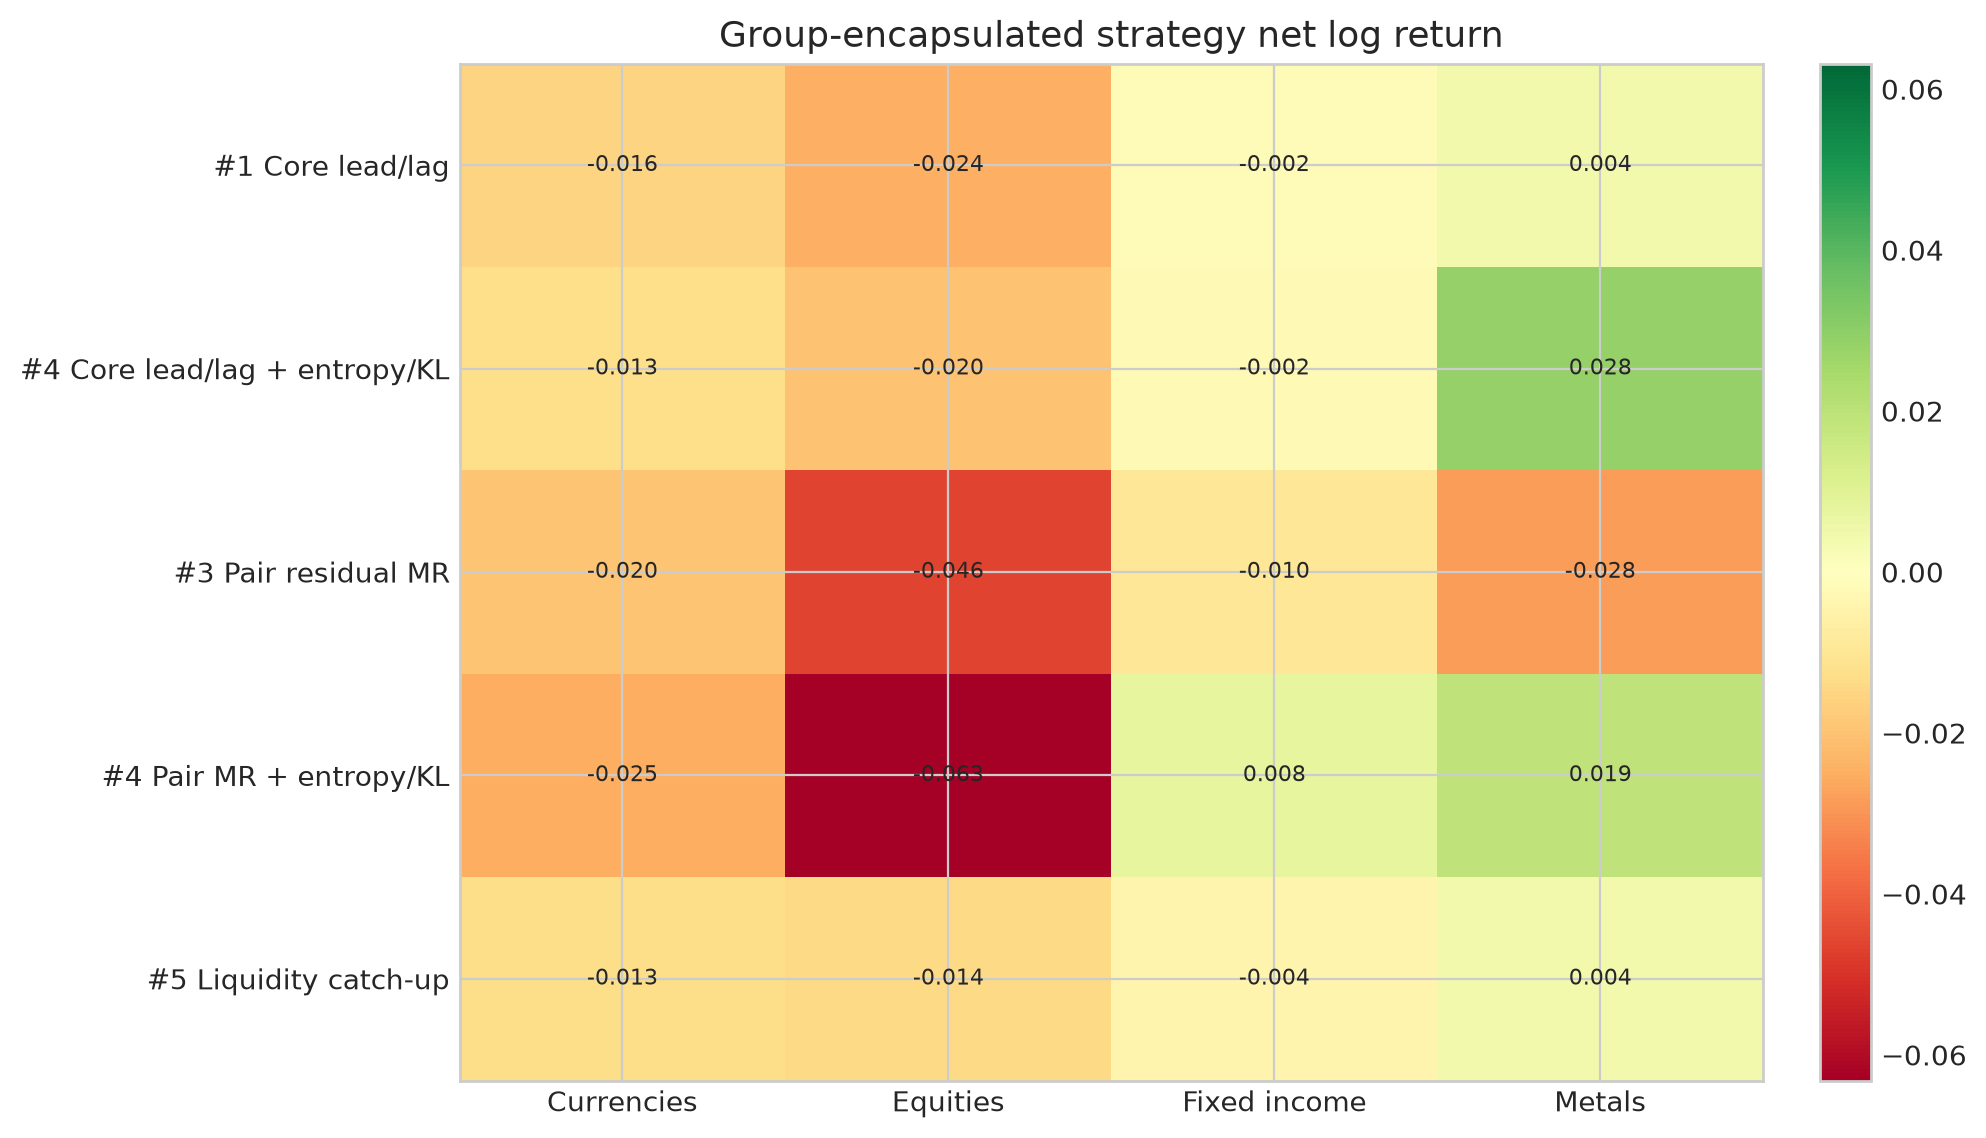

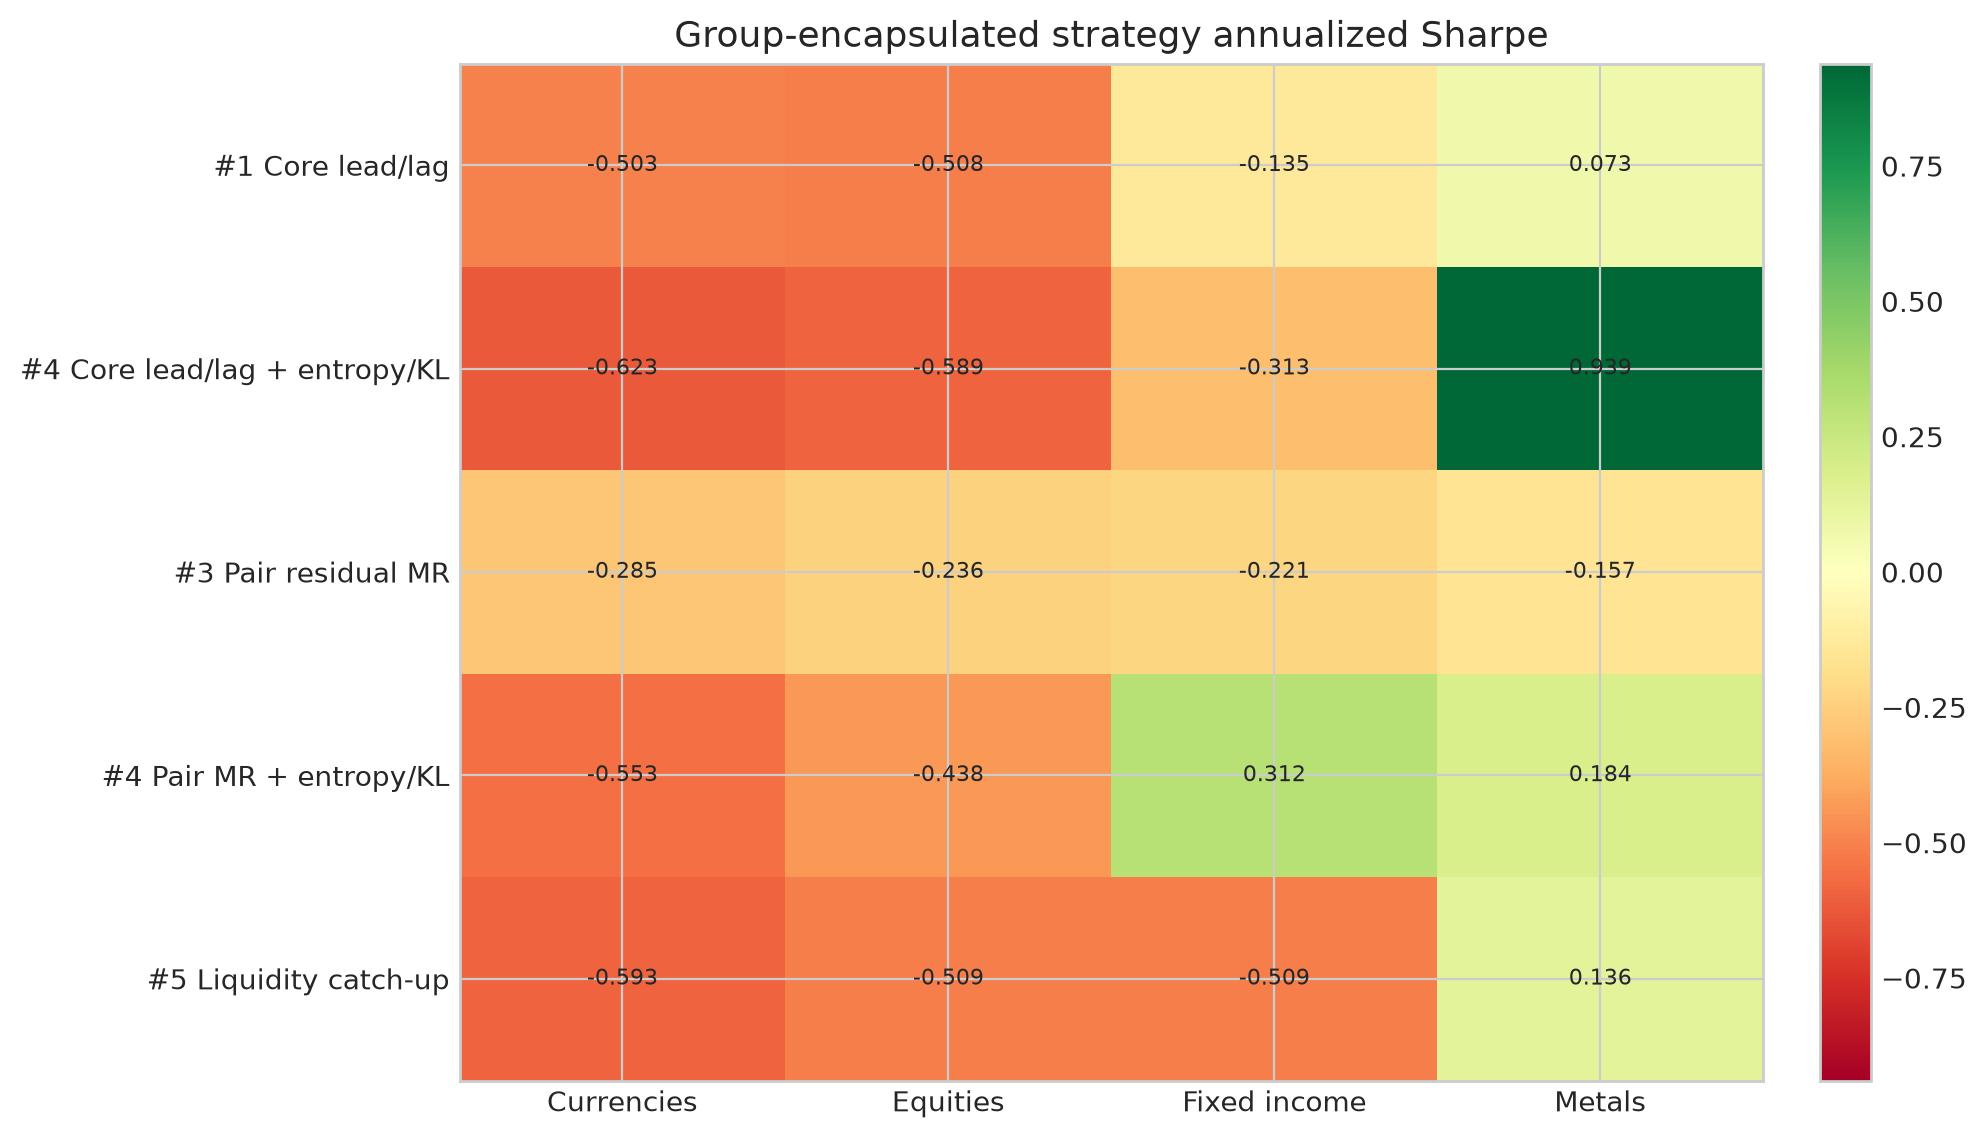

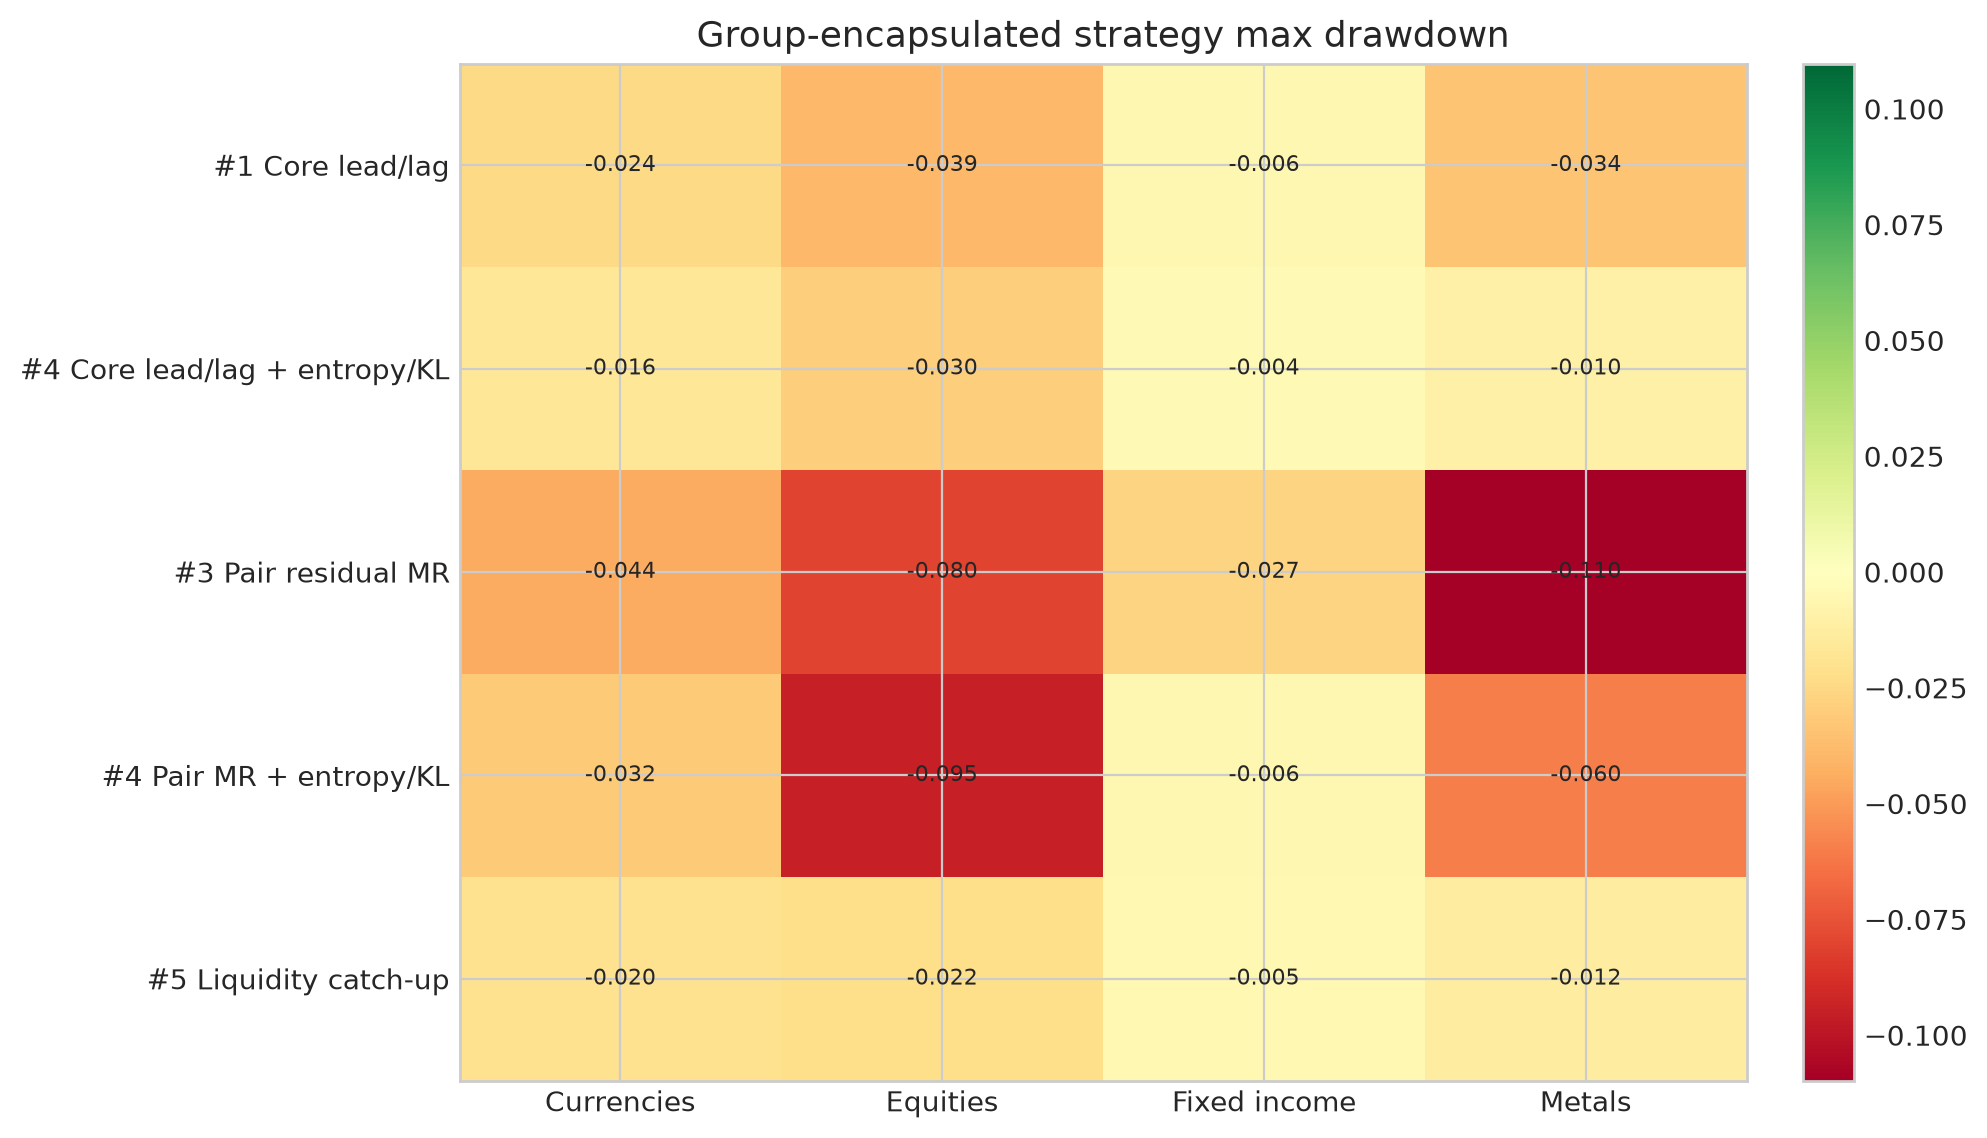

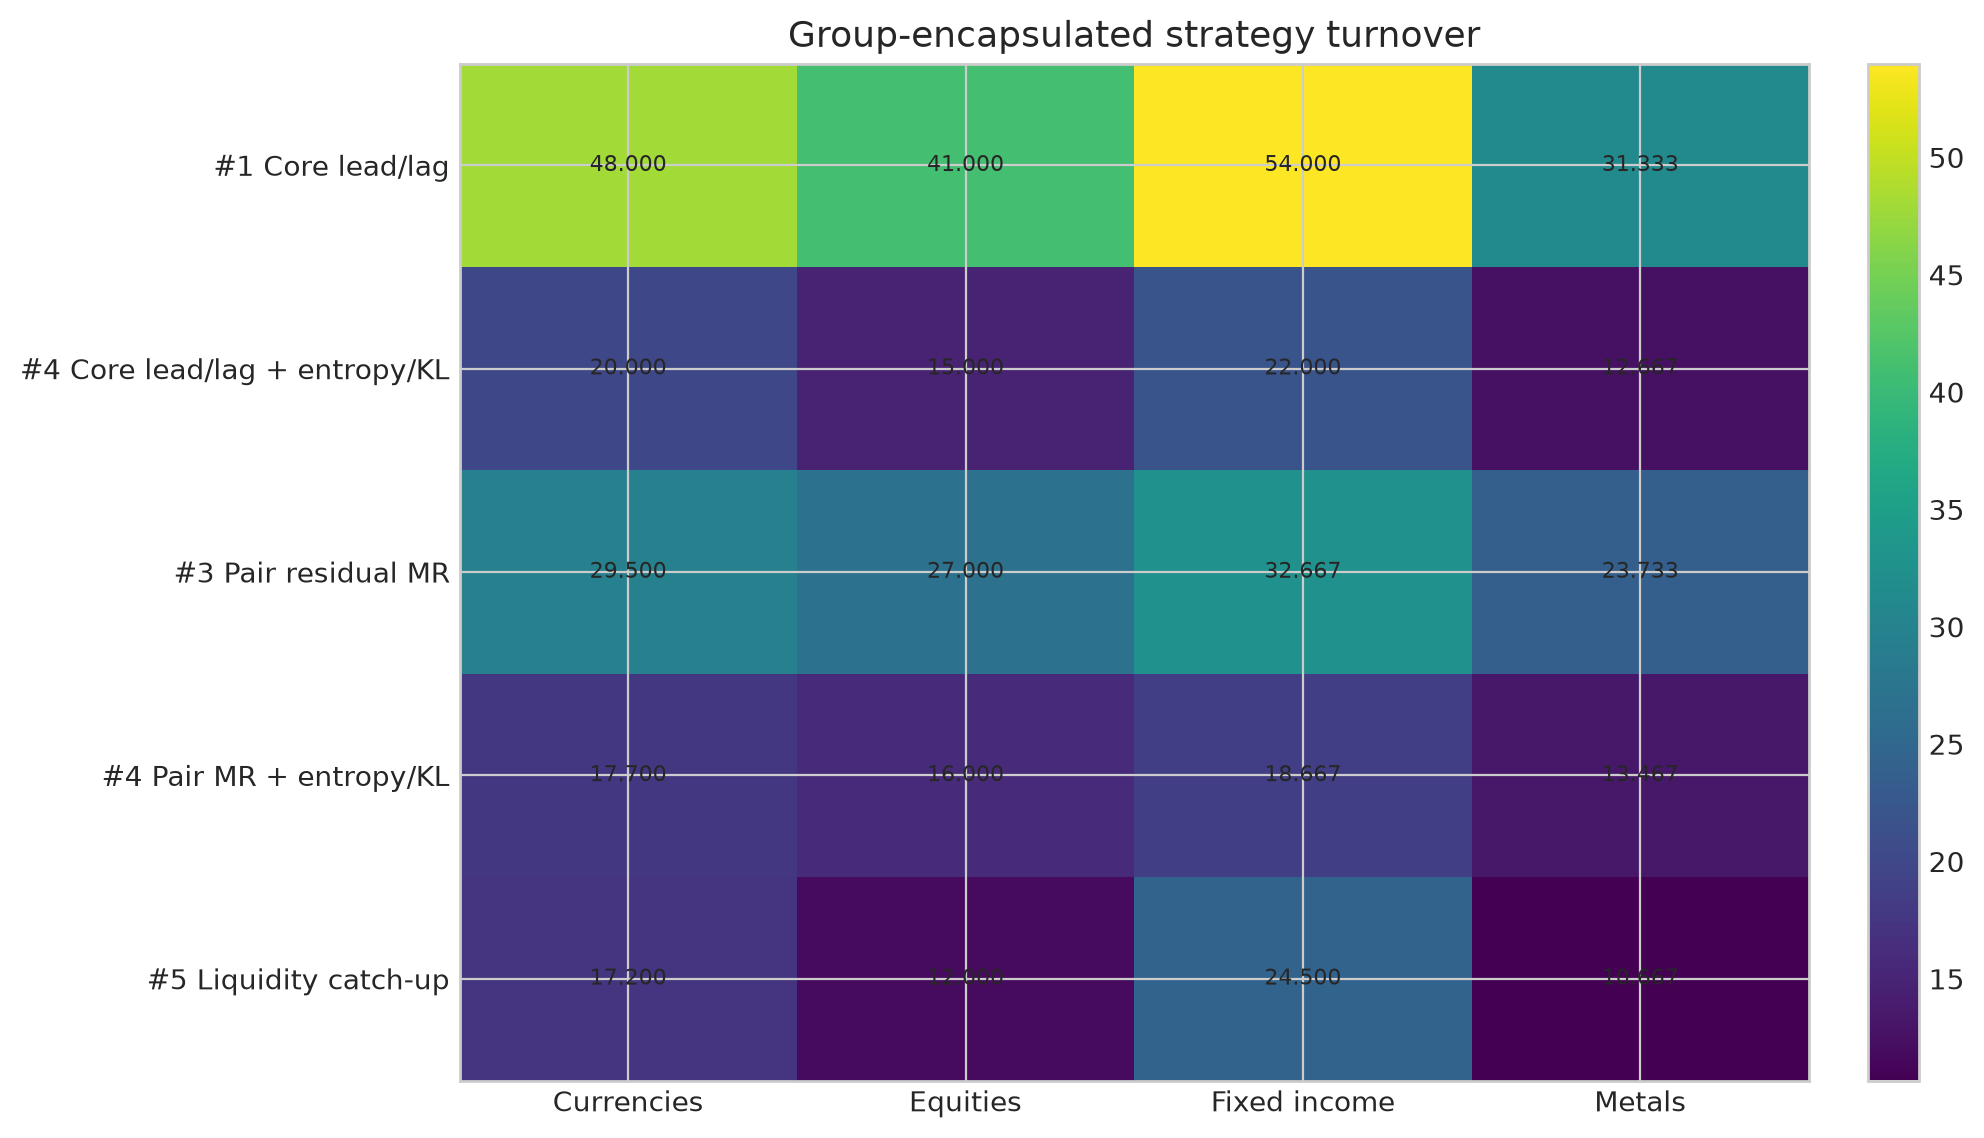

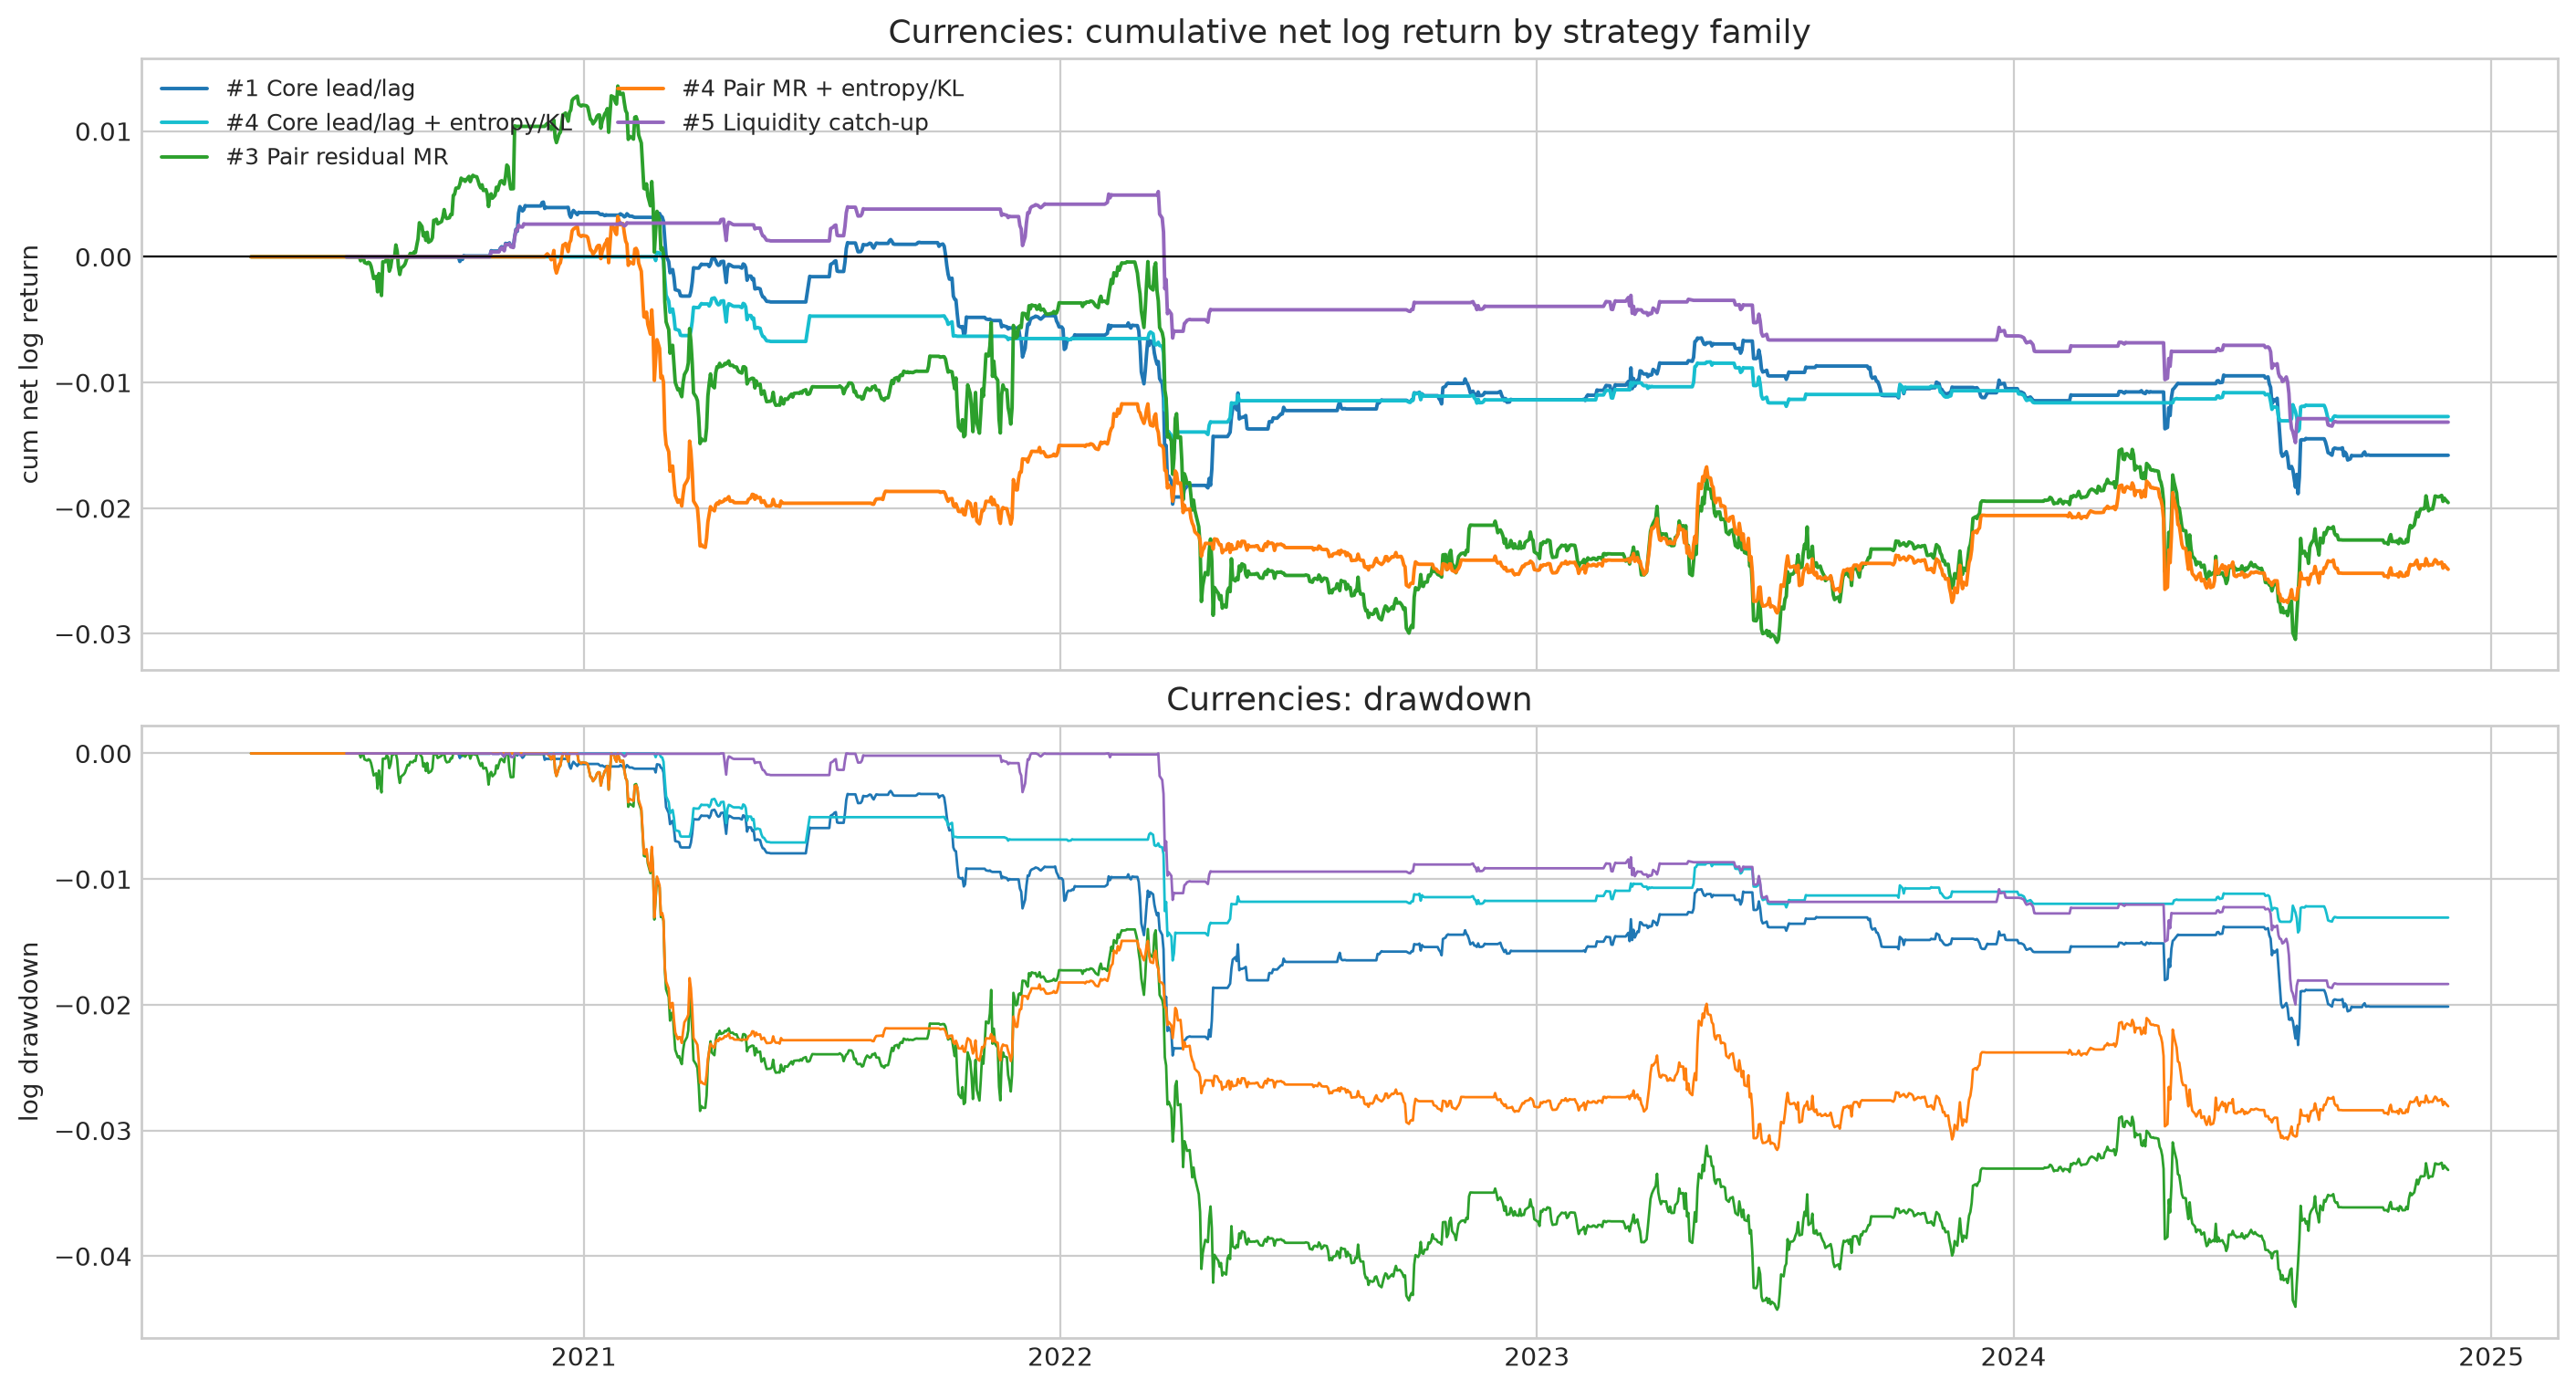

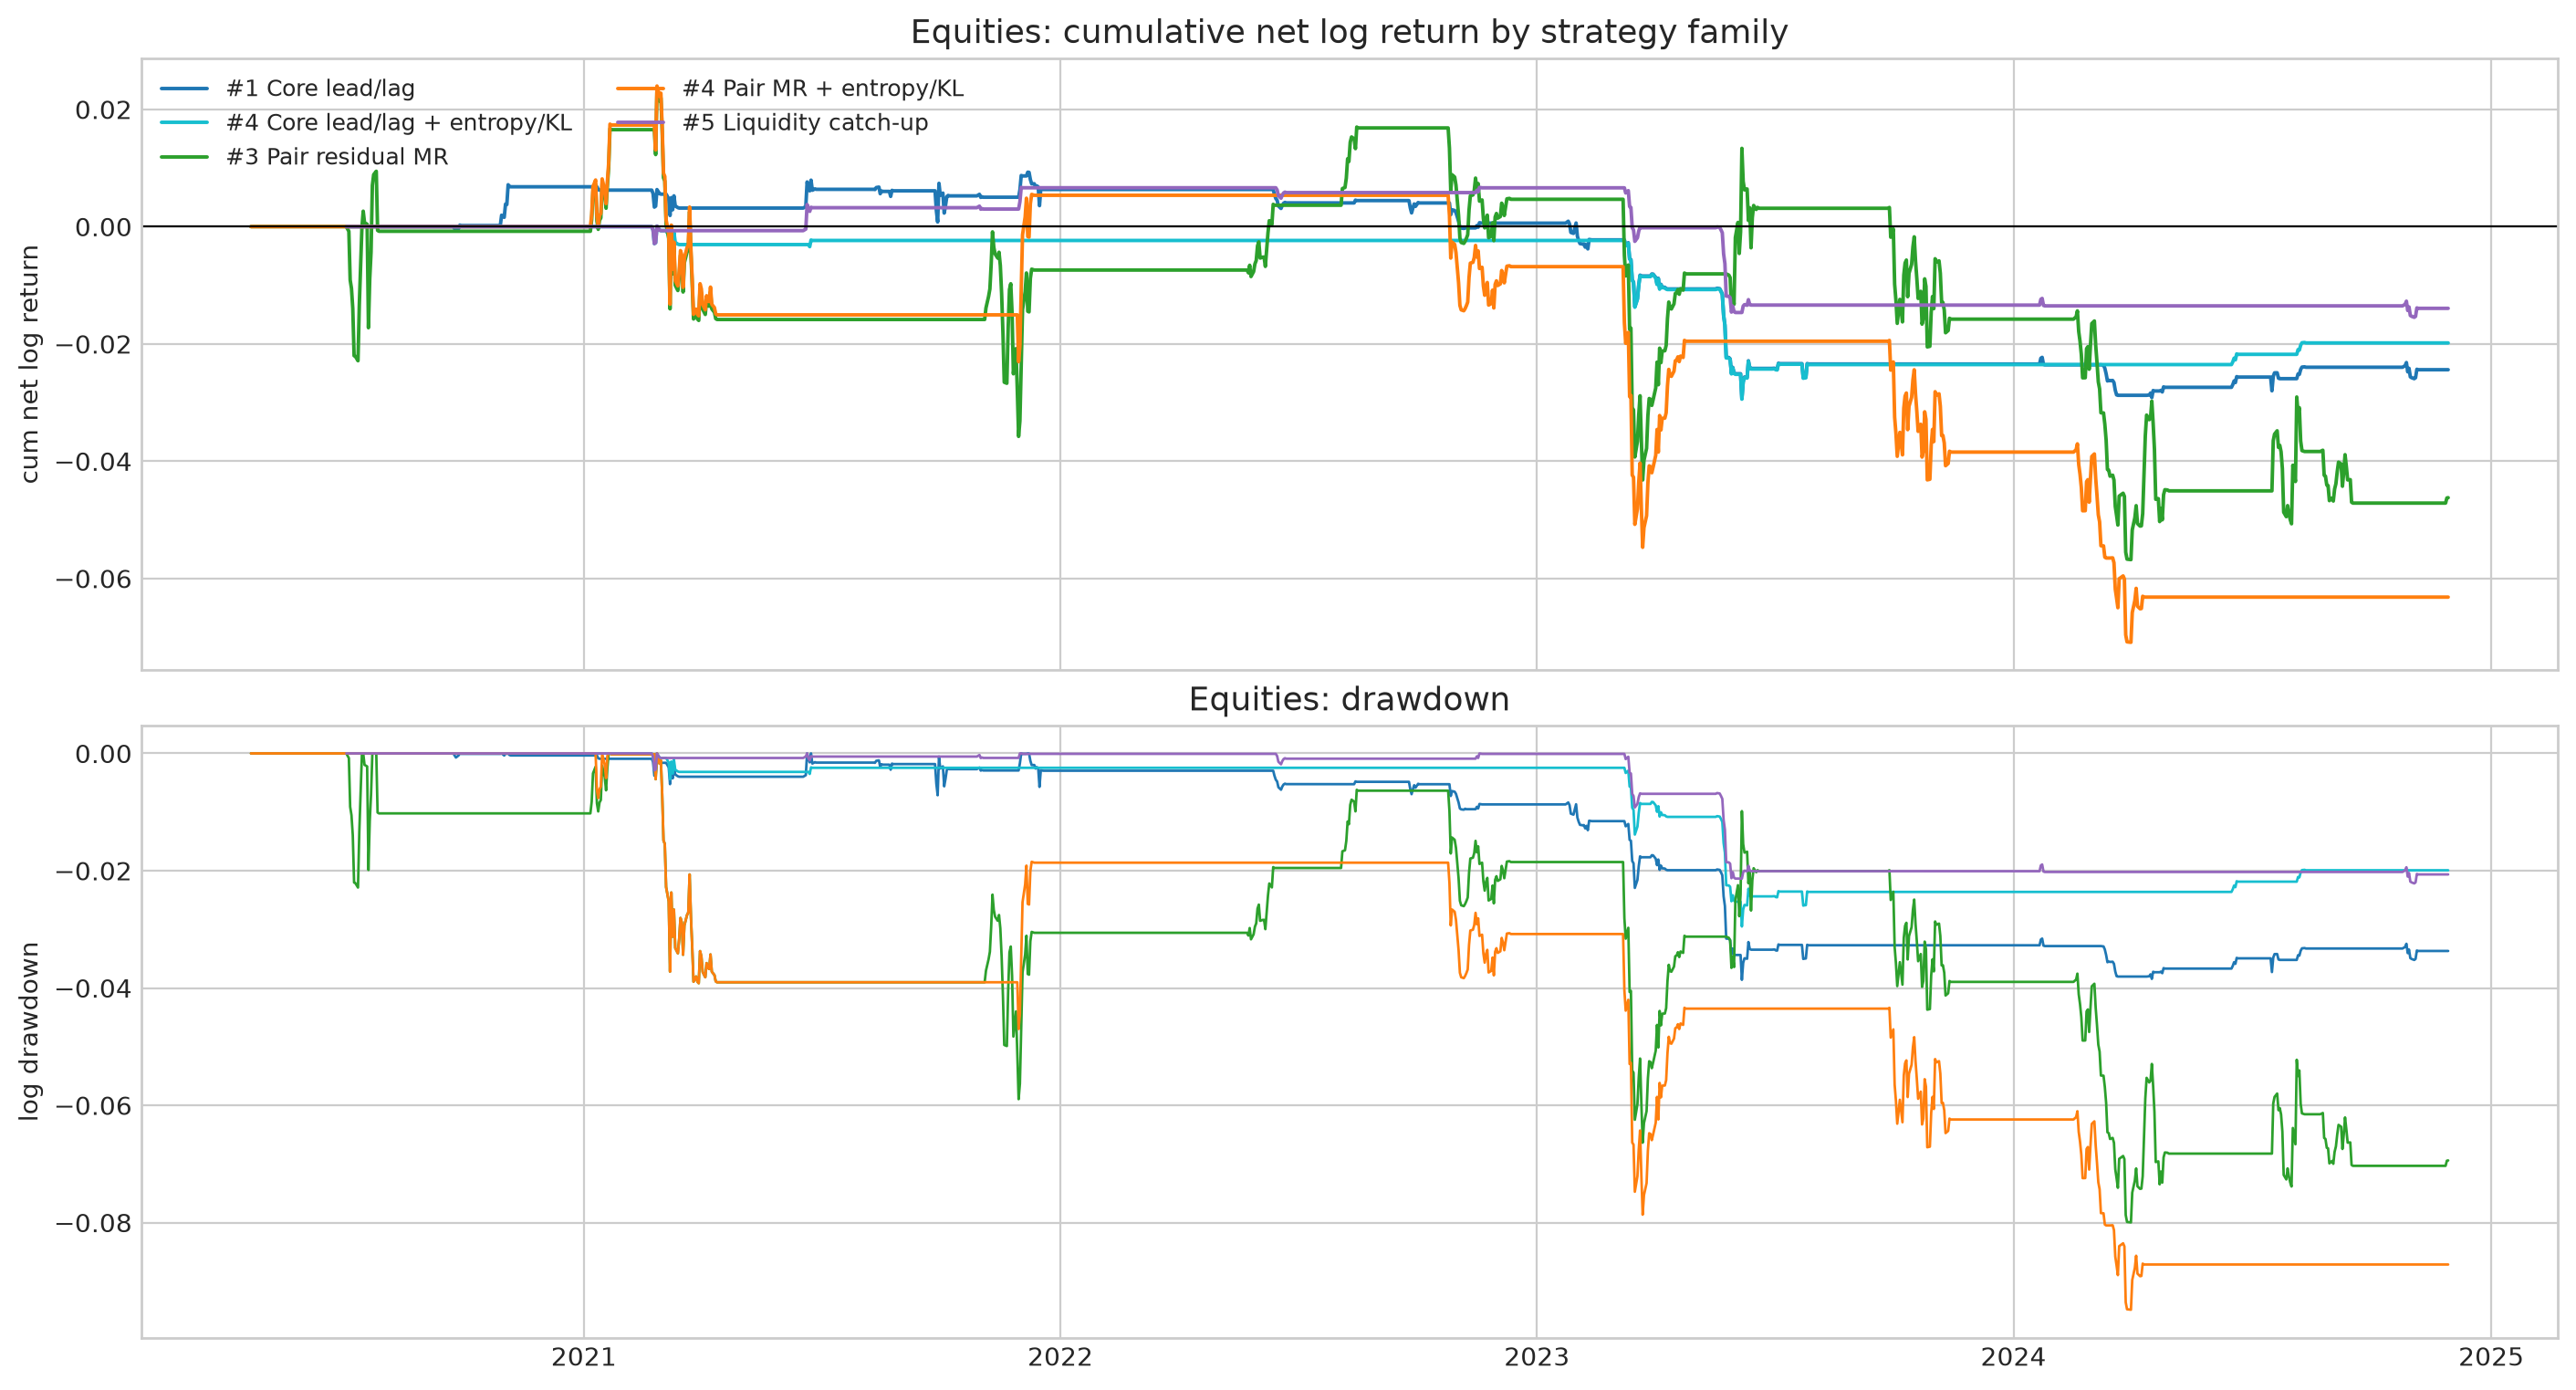

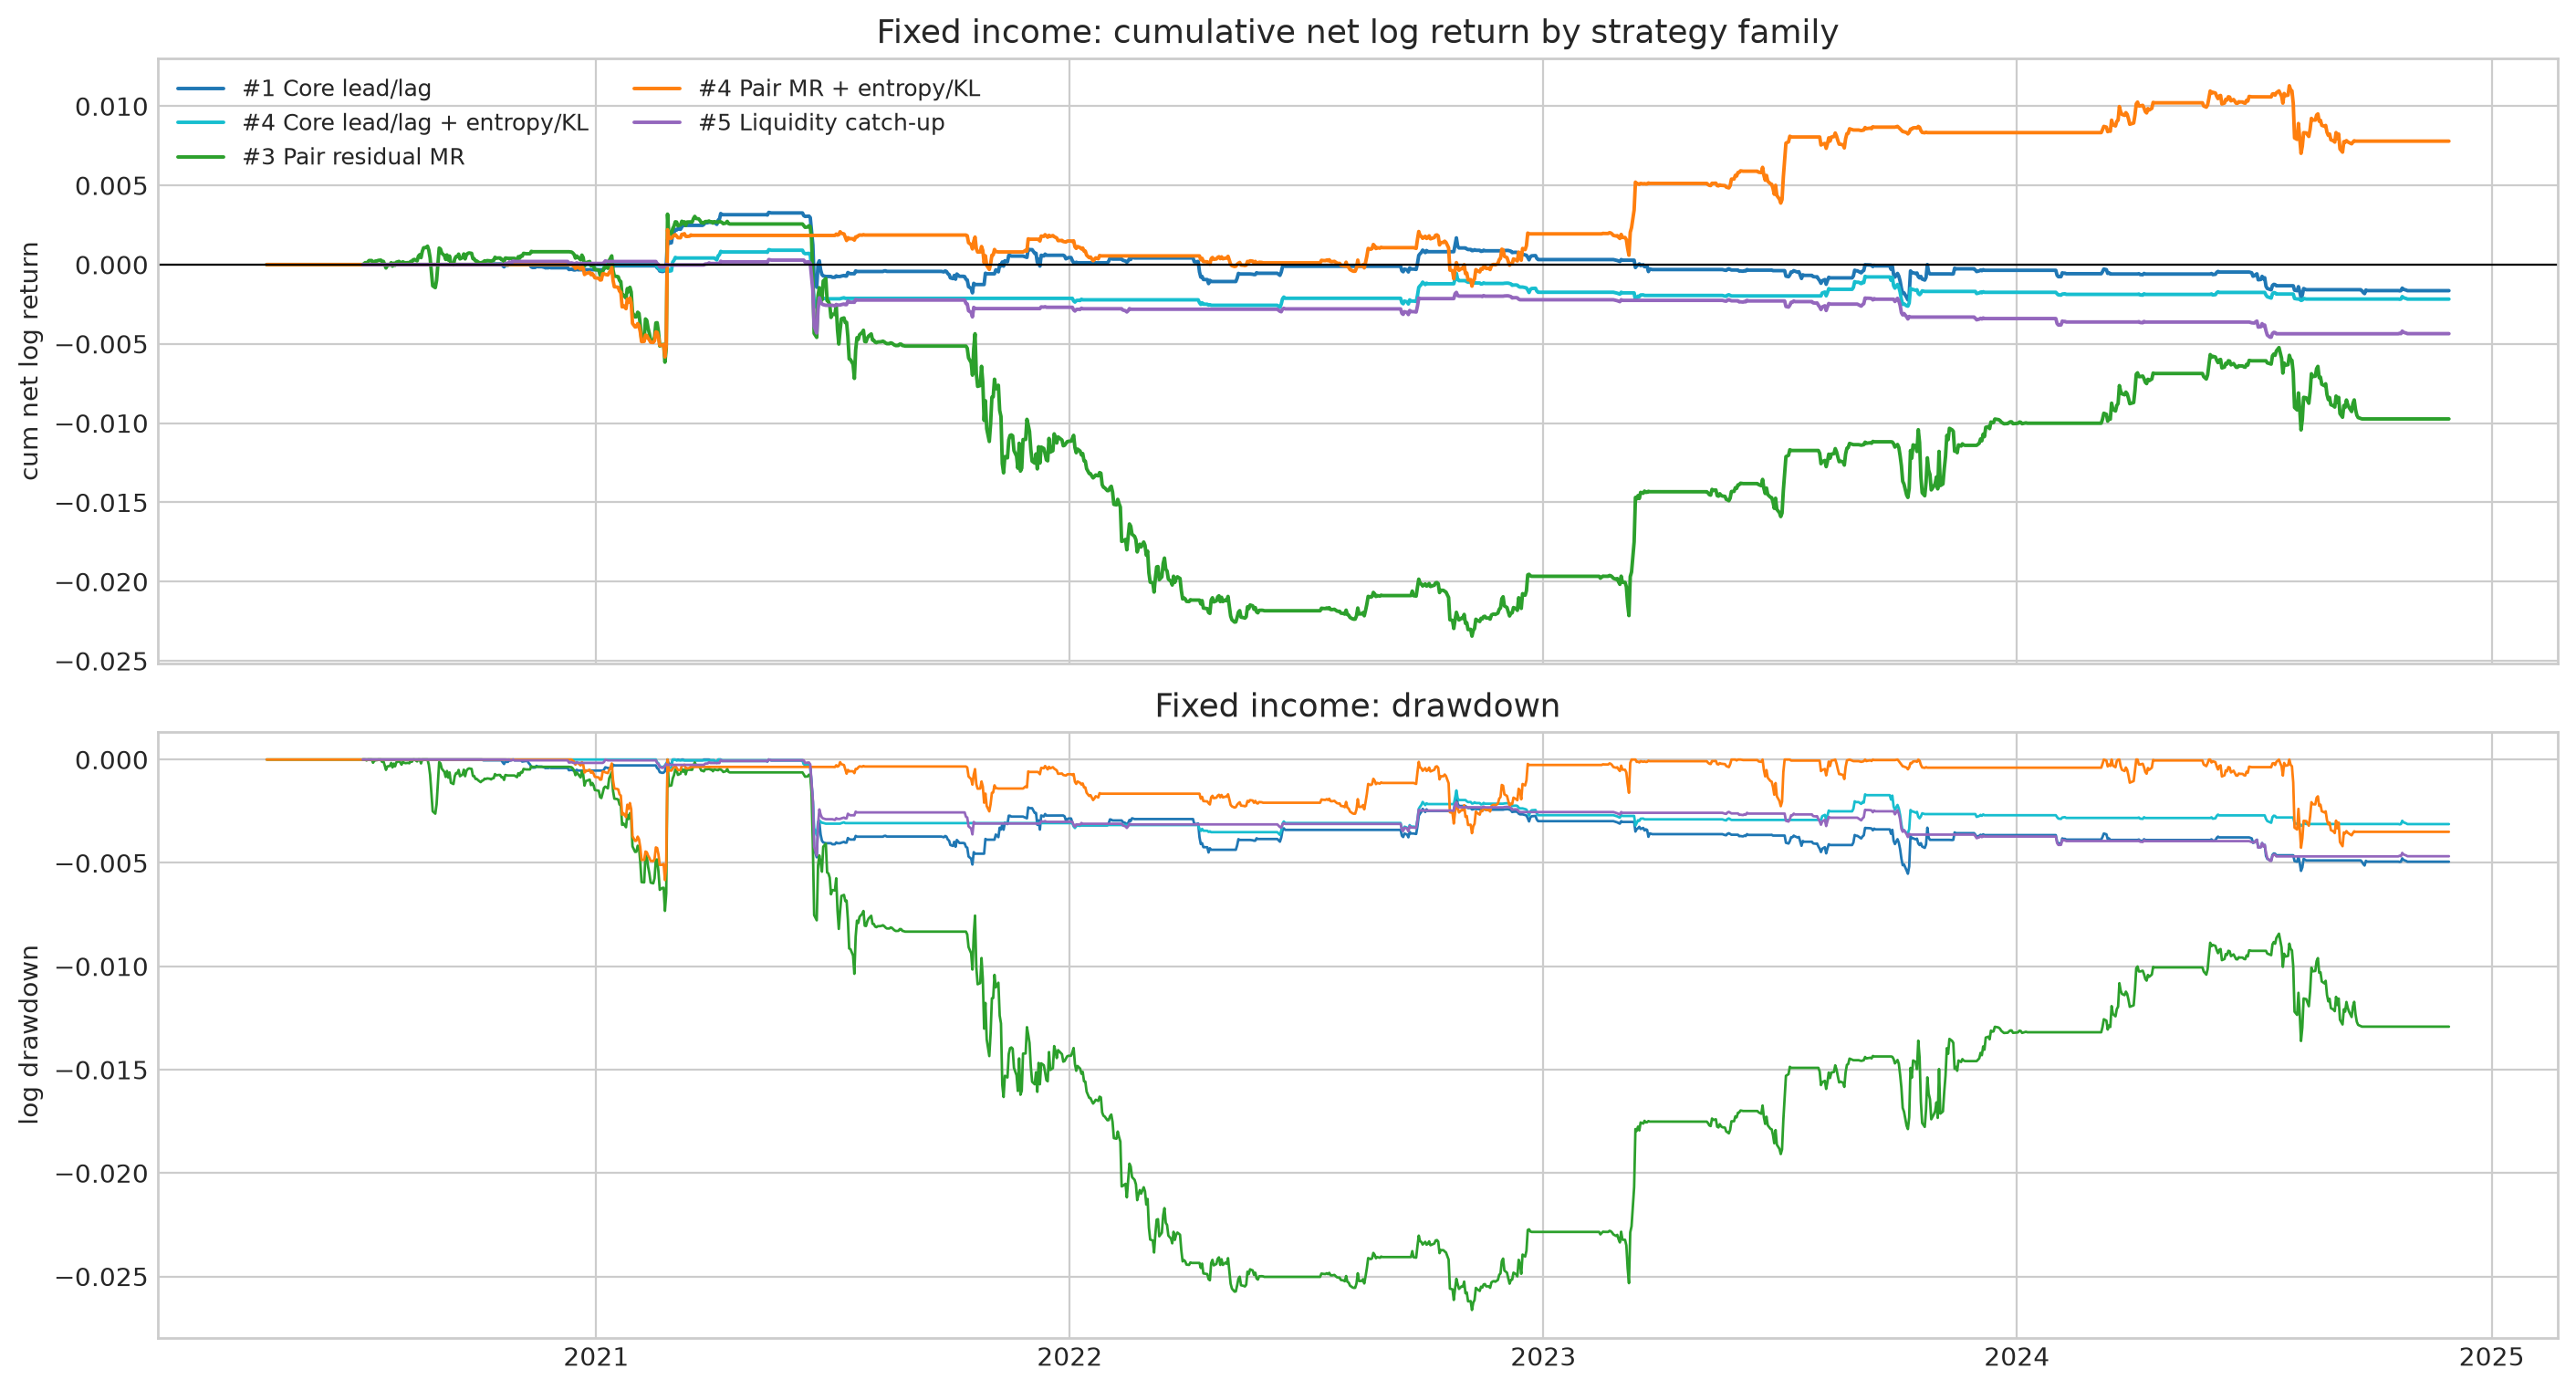

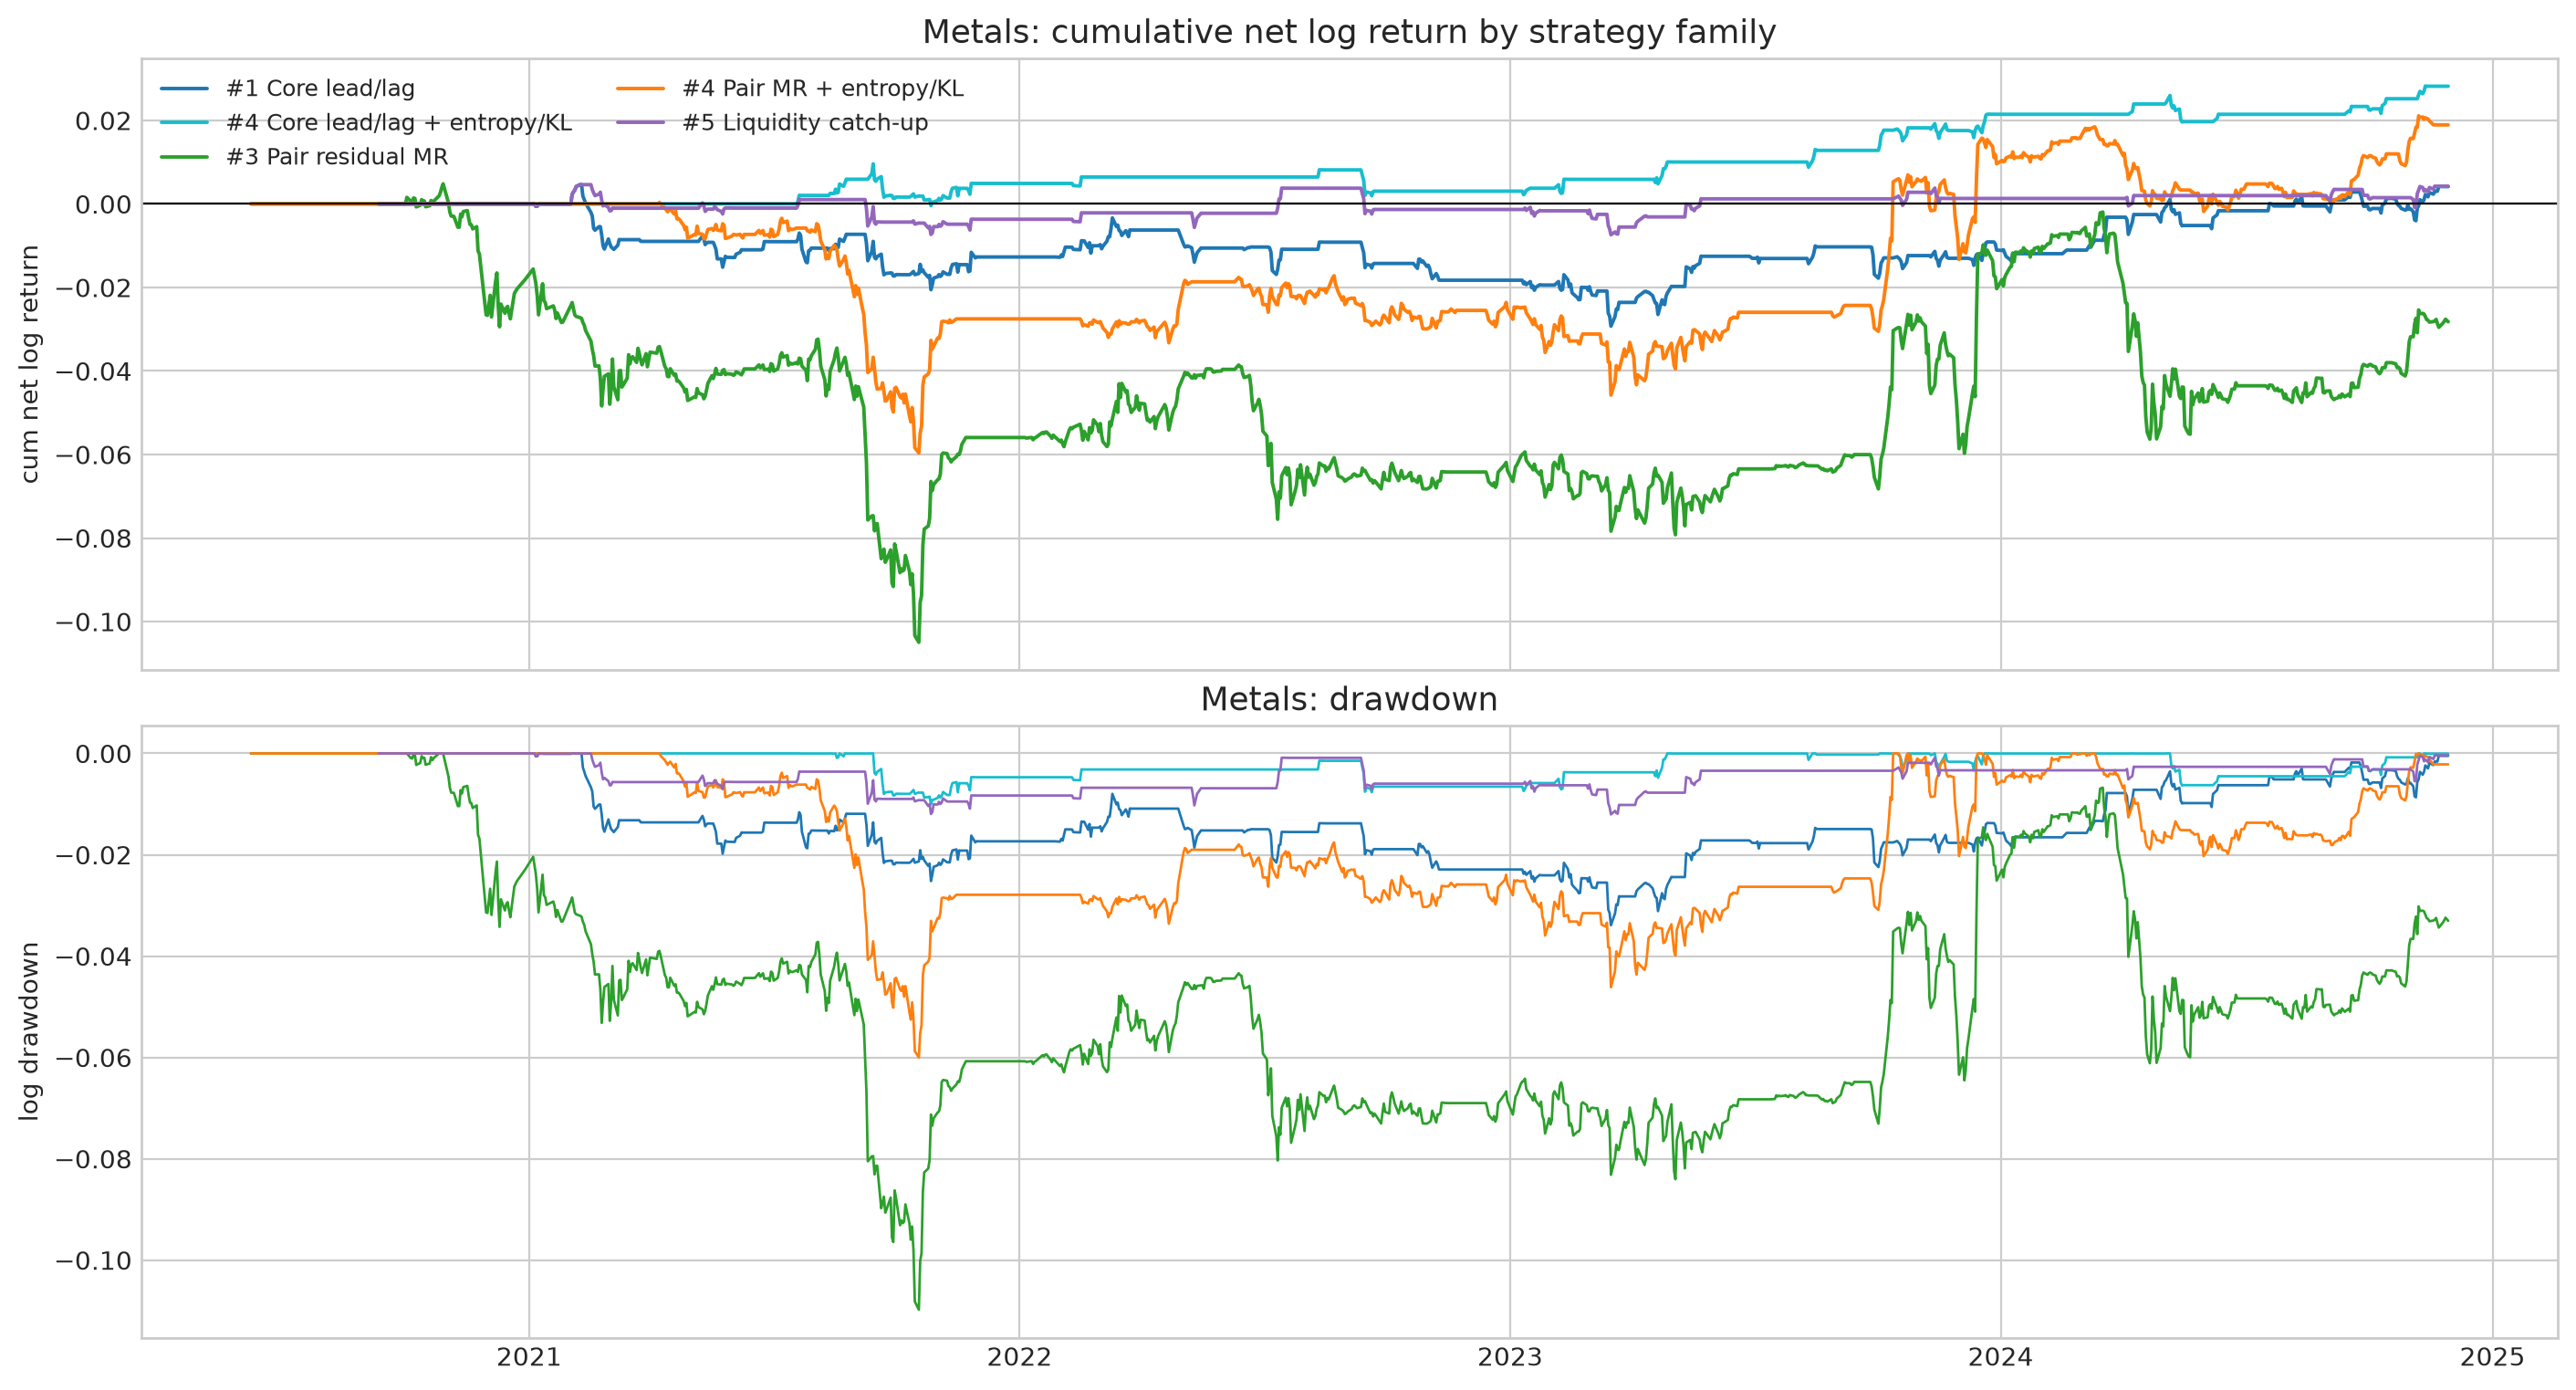

In [4]:
for metric, title, cmap, center in [
    ("net_log_return", "Group-encapsulated strategy net log return", "RdYlGn", 0.0),
    ("annualized_sharpe", "Group-encapsulated strategy annualized Sharpe", "RdYlGn", 0.0),
    ("max_drawdown_log", "Group-encapsulated strategy max drawdown", "RdYlGn", 0.0),
    ("total_turnover", "Group-encapsulated strategy turnover", "viridis", None),
]:
    matrix = strategy_metrics.pivot(index="strategy_label", columns="group", values=metric)
    matrix = matrix.reindex([STRATEGY_LABELS[strategy] for strategy in STRATEGY_ORDER])
    matrix = matrix.reindex(columns=[group for group in GROUP_ORDER if group in matrix.columns])
    values = matrix.to_numpy(dtype=float)
    fig, axis = plt.subplots(figsize=(10, 5.8))
    if center is None:
        norm = None
    else:
        limit = np.nanmax(np.abs(values))
        norm = TwoSlopeNorm(vcenter=0.0, vmin=-limit, vmax=limit) if limit > 0 else None
    image = axis.imshow(values, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)
    axis.set_xticks(range(matrix.shape[1]))
    axis.set_xticklabels(matrix.columns)
    axis.set_yticks(range(matrix.shape[0]))
    axis.set_yticklabels(matrix.index)
    axis.set_title(title)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = values[row, col]
            if np.isfinite(value):
                axis.text(col, row, f"{value:.3f}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

for group in [group for group in GROUP_ORDER if group != "Energy"]:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True, constrained_layout=True)
    for strategy in STRATEGY_ORDER:
        subset = component_returns.loc[
            (component_returns["group"] == group) & (component_returns["strategy"] == strategy)
        ].copy()
        if subset.empty:
            continue
        wide = subset.pivot_table(
            index=subset.index, columns="component", values="net_return", aggfunc="sum"
        ).fillna(0.0)
        curve = wide.mean(axis=1).cumsum()
        drawdown = curve - curve.cummax()
        axes[0].plot(
            curve.index,
            curve,
            label=STRATEGY_LABELS[strategy],
            color=STRATEGY_COLORS[strategy],
            linewidth=1.4,
        )
        axes[1].plot(
            drawdown.index,
            drawdown,
            label=STRATEGY_LABELS[strategy],
            color=STRATEGY_COLORS[strategy],
            linewidth=1.0,
        )
    axes[0].axhline(0.0, color="black", linewidth=0.8)
    axes[0].set_title(f"{group}: cumulative net log return by strategy family")
    axes[0].set_ylabel("cum net log return")
    axes[0].legend(ncol=2, loc="upper left")
    axes[1].set_title(f"{group}: drawdown")
    axes[1].set_ylabel("log drawdown")
    axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.show()

## Component And Monthly Diagnostics

,group,strategy_label,component,net_log_return,annualized_sharpe,max_drawdown_log,active_fraction,total_turnover
114,Metals,#4 Pair MR + entropy/KL,SI-PL,0.1761,1.2209,-0.0337,0.0452,10.0
99,Metals,#3 Pair residual MR,SI-PL,0.3000,1.0570,-0.1039,0.1931,24.0
19,Currencies,#3 Pair residual MR,6B-6C,0.1140,1.0117,-0.0197,0.2383,36.0
76,Metals,#4 Core lead/lag + entropy/KL,PA,0.0659,0.9141,-0.0125,0.0216,12.0
47,Fixed income,#4 Core lead/lag + entropy/KL,ZB,0.0128,0.9001,-0.0023,0.0248,18.0
112,Metals,#4 Pair MR + entropy/KL,SI-HG,0.1688,0.7762,-0.0735,0.0859,14.0
43,Fixed income,#1 Core lead/lag,ZB,0.0178,0.7681,-0.0044,0.0605,44.0
73,Metals,#4 Core lead/lag + entropy/KL,ALI,0.0508,0.6068,-0.0231,0.0272,14.0
84,Metals,#5 Liquidity catch-up,SI,0.0333,0.5863,-0.0212,0.0281,12.0
81,Metals,#5 Liquidity catch-up,HG,0.0396,0.5803,-0.0142,0.0197,8.0


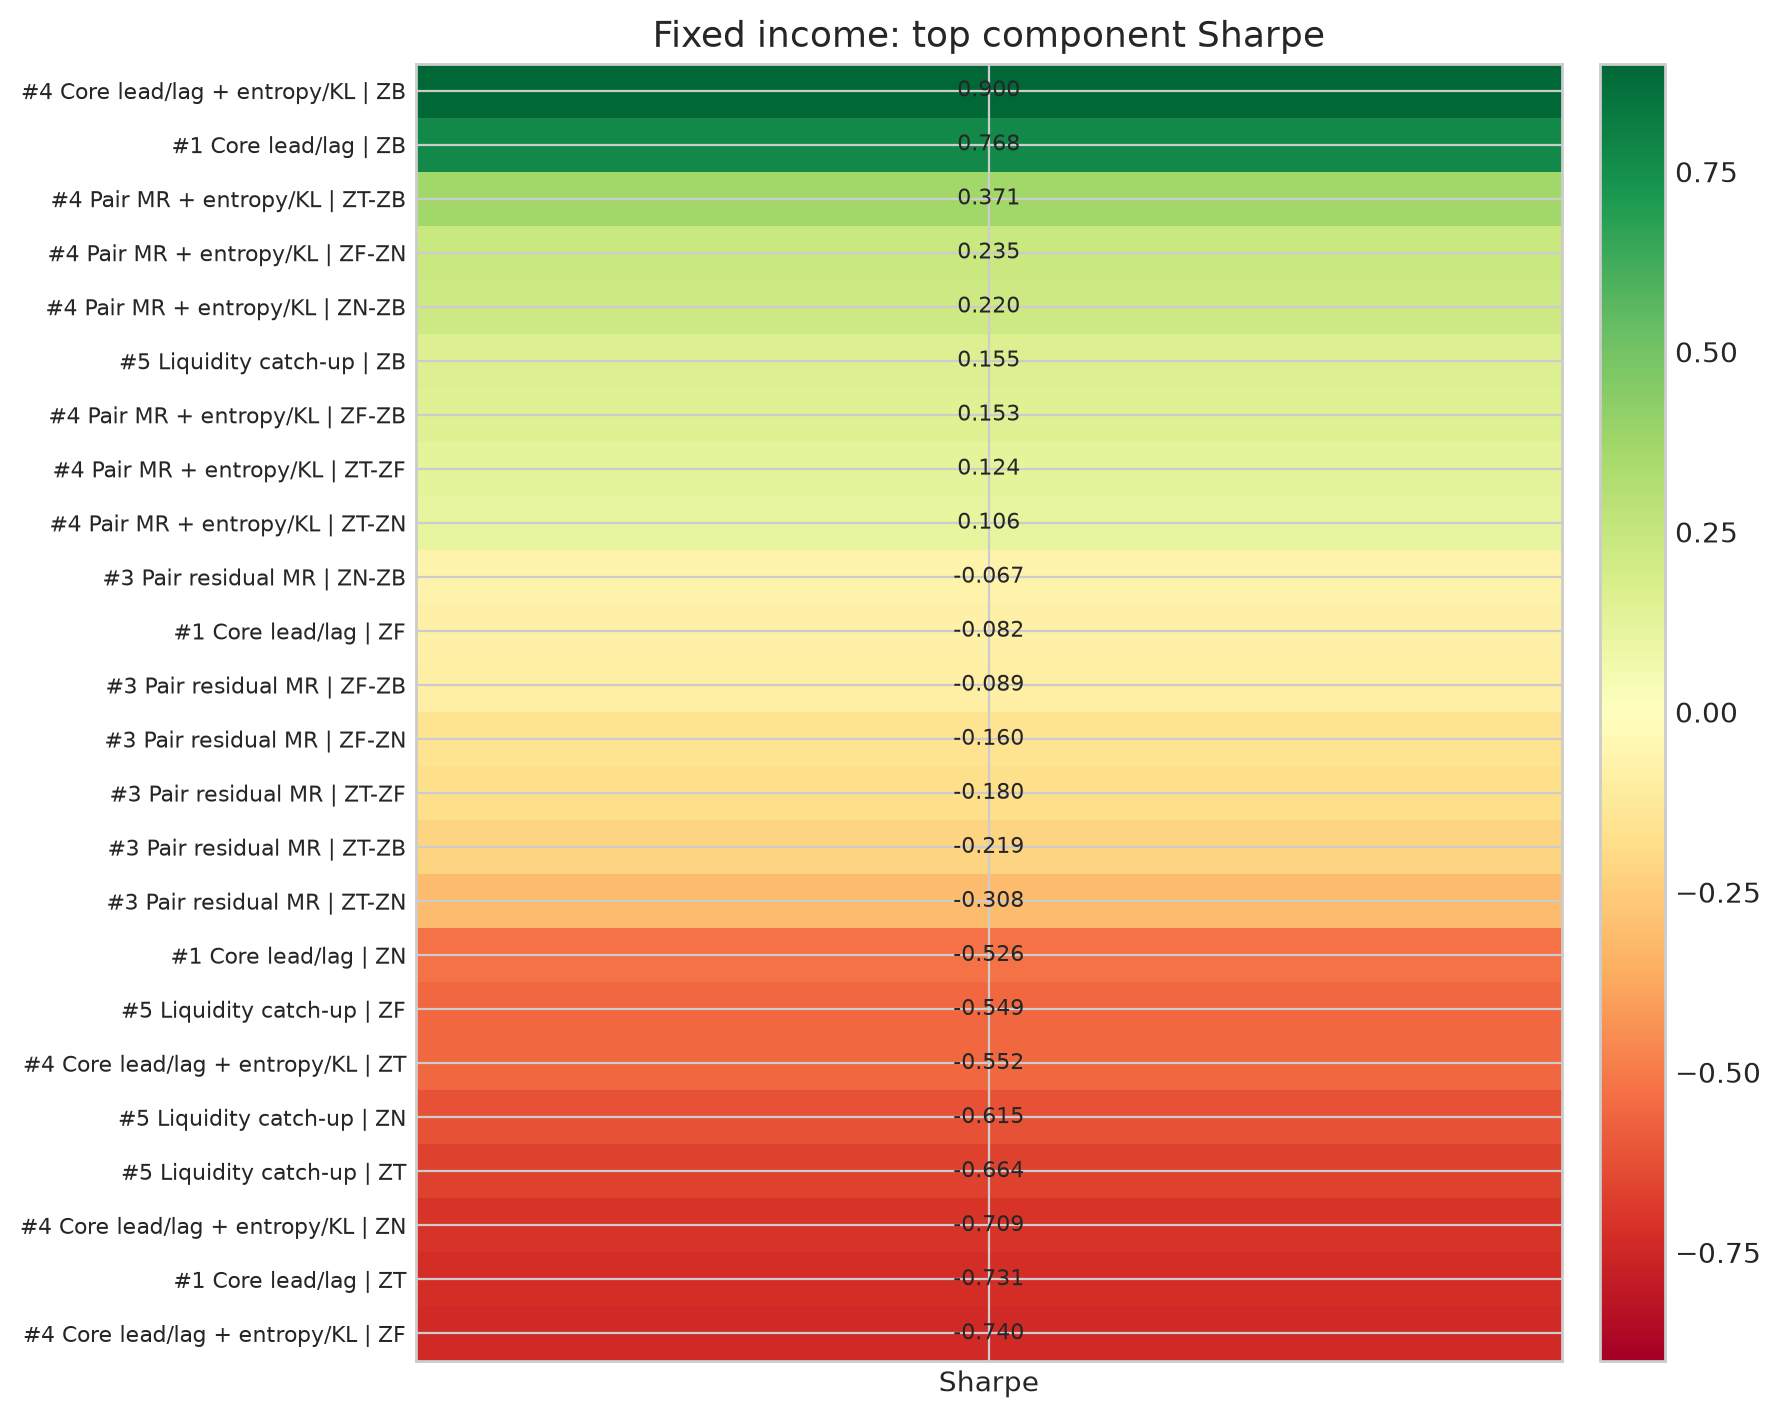

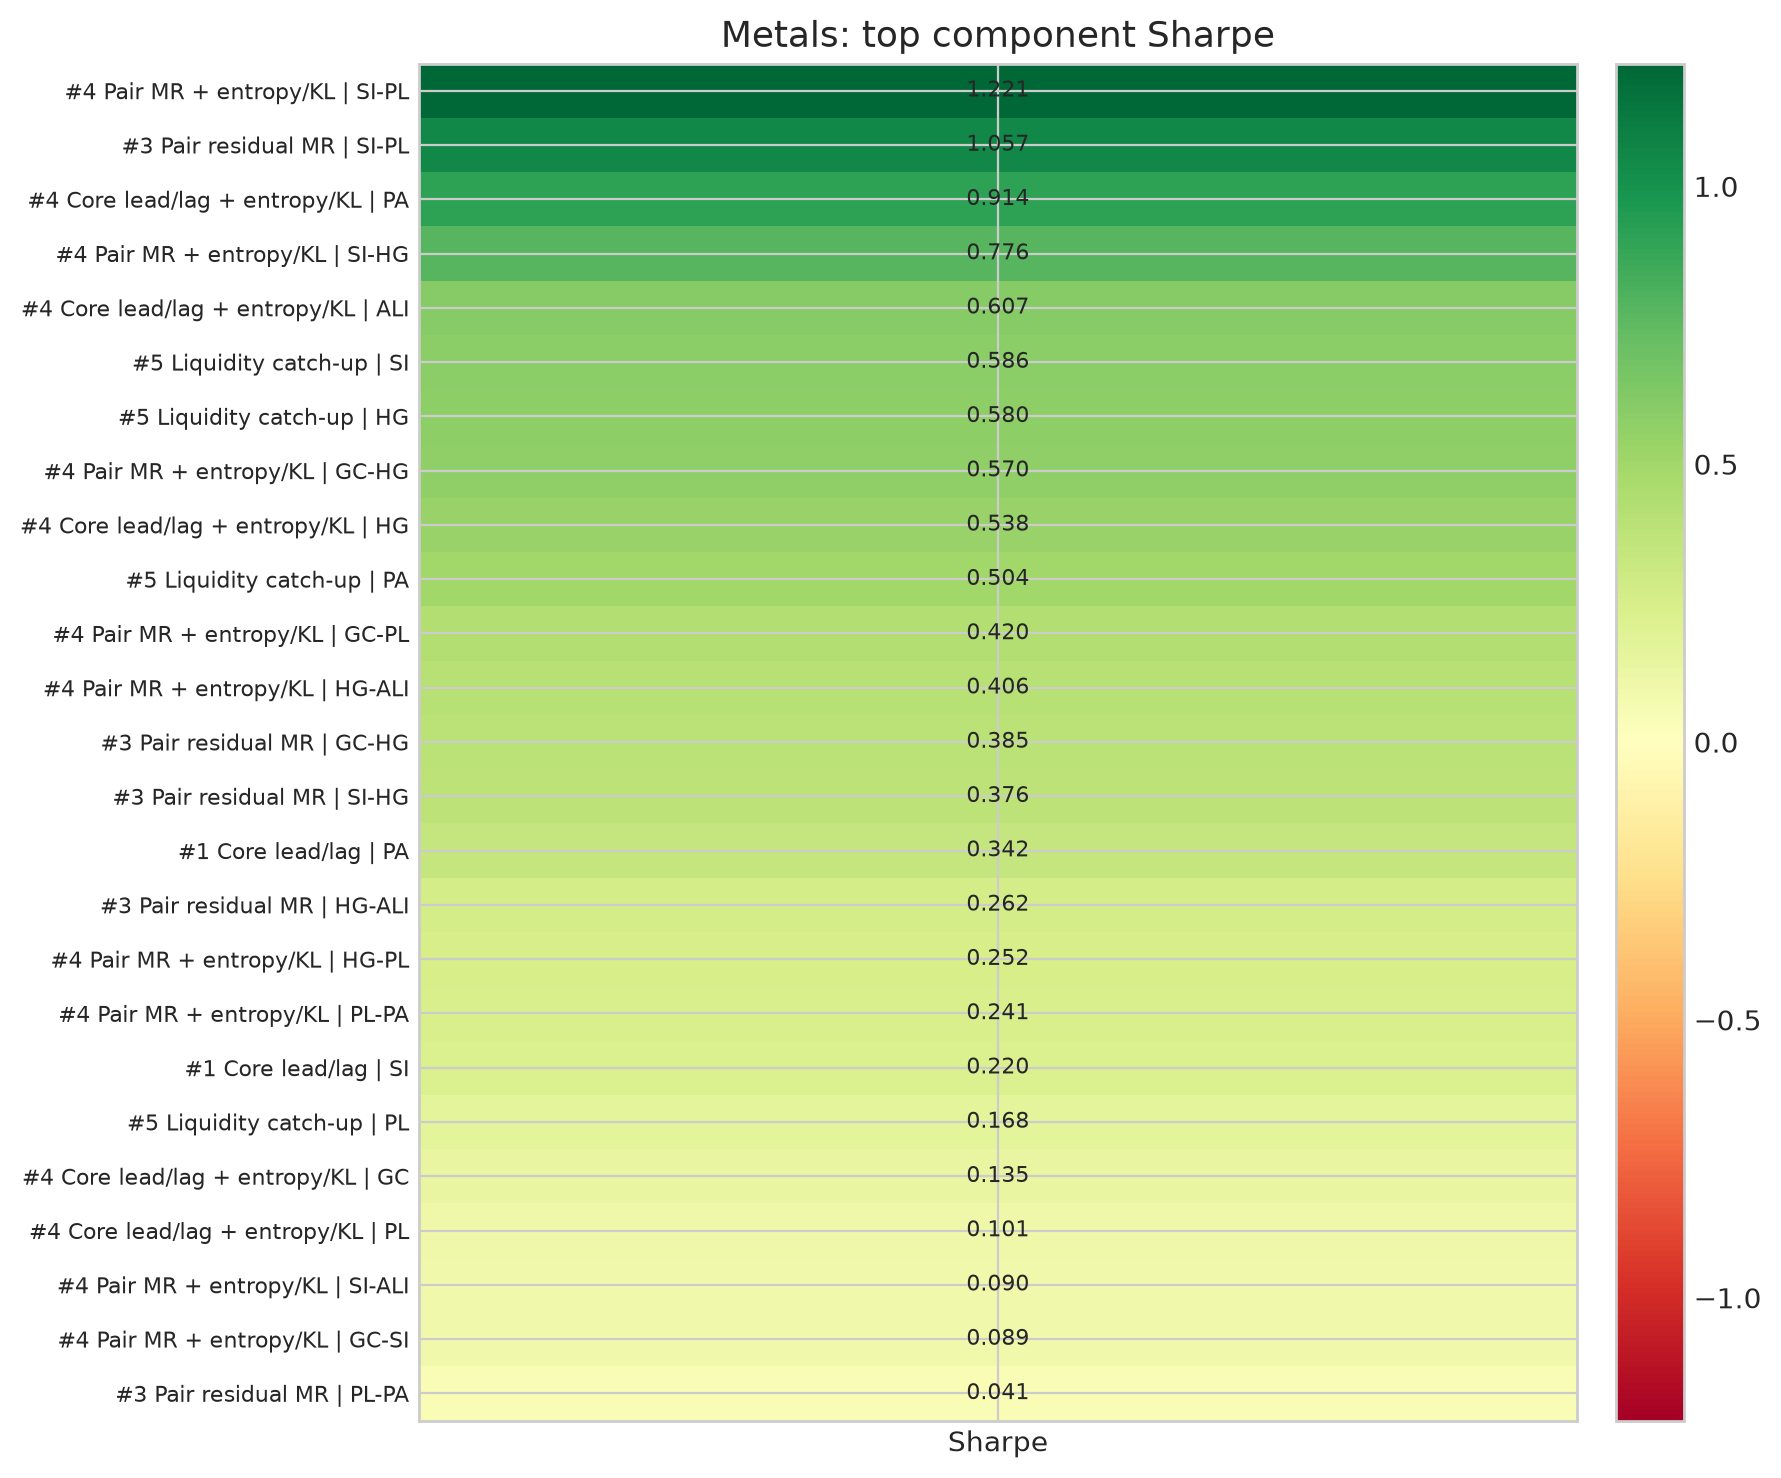

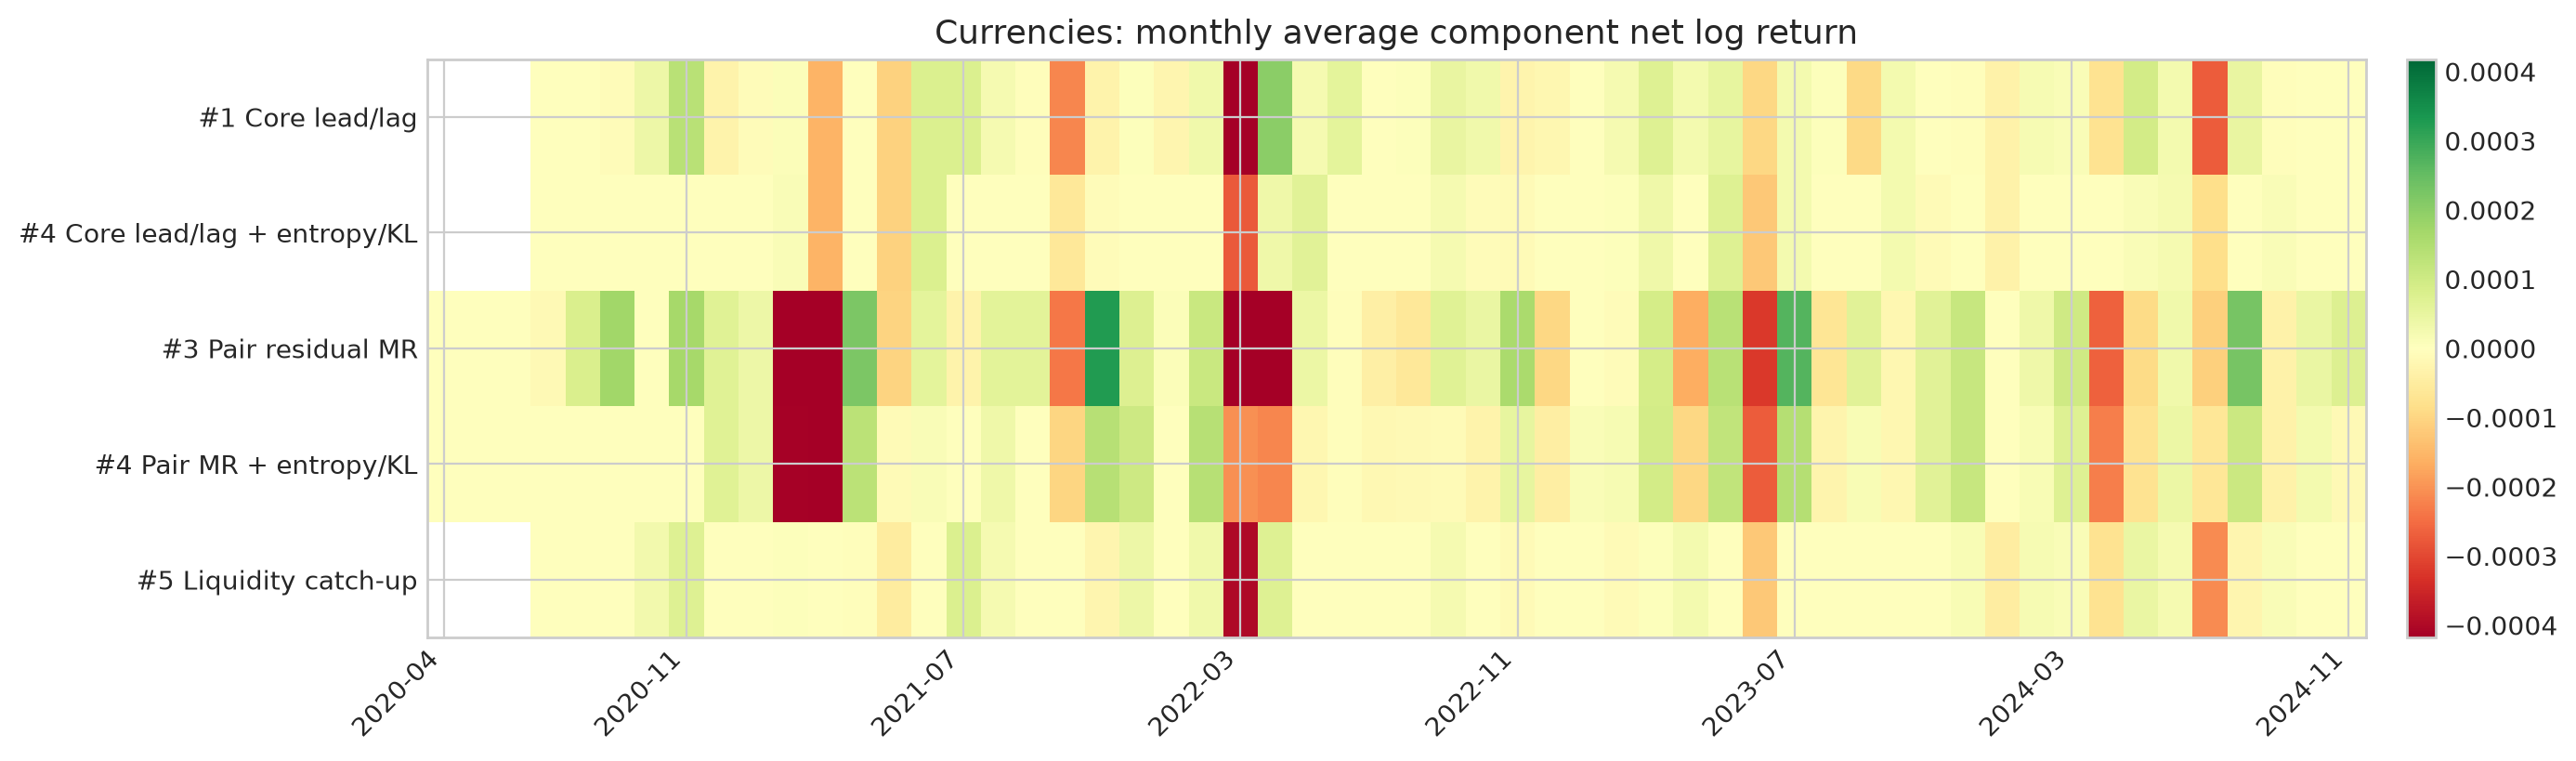

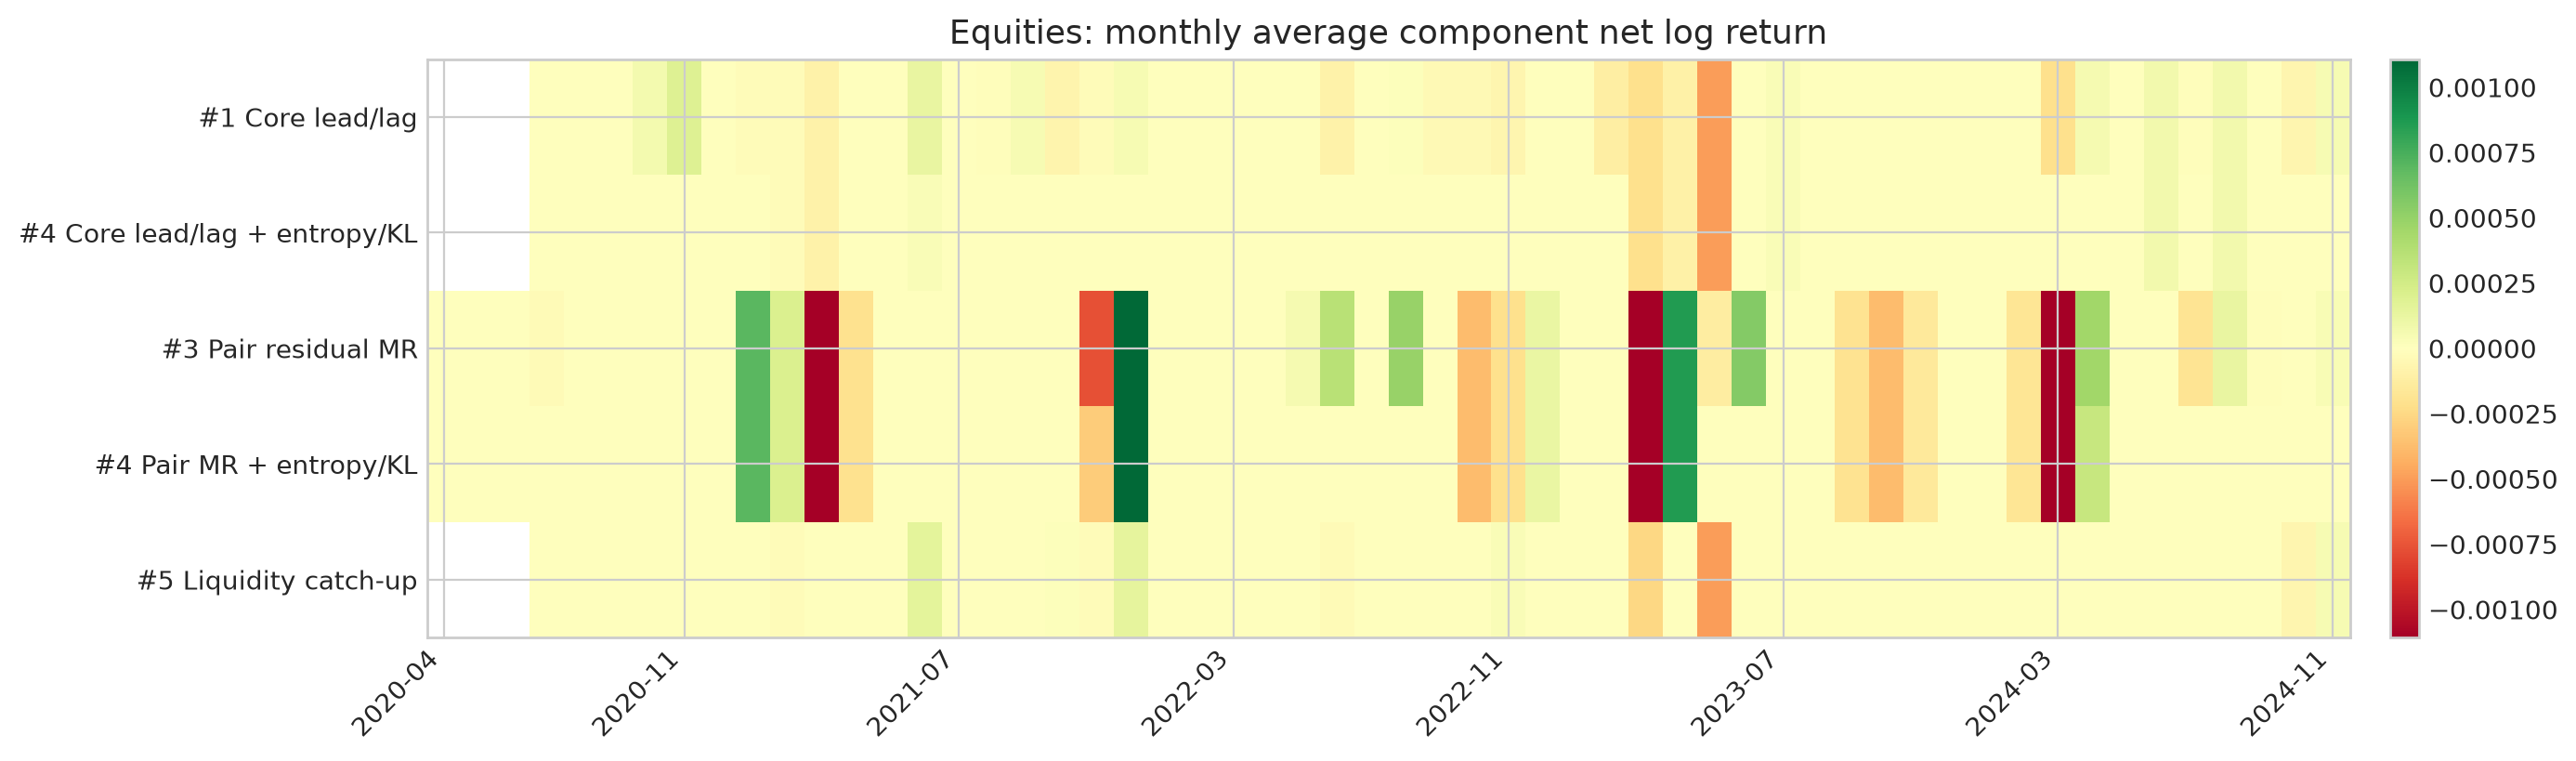

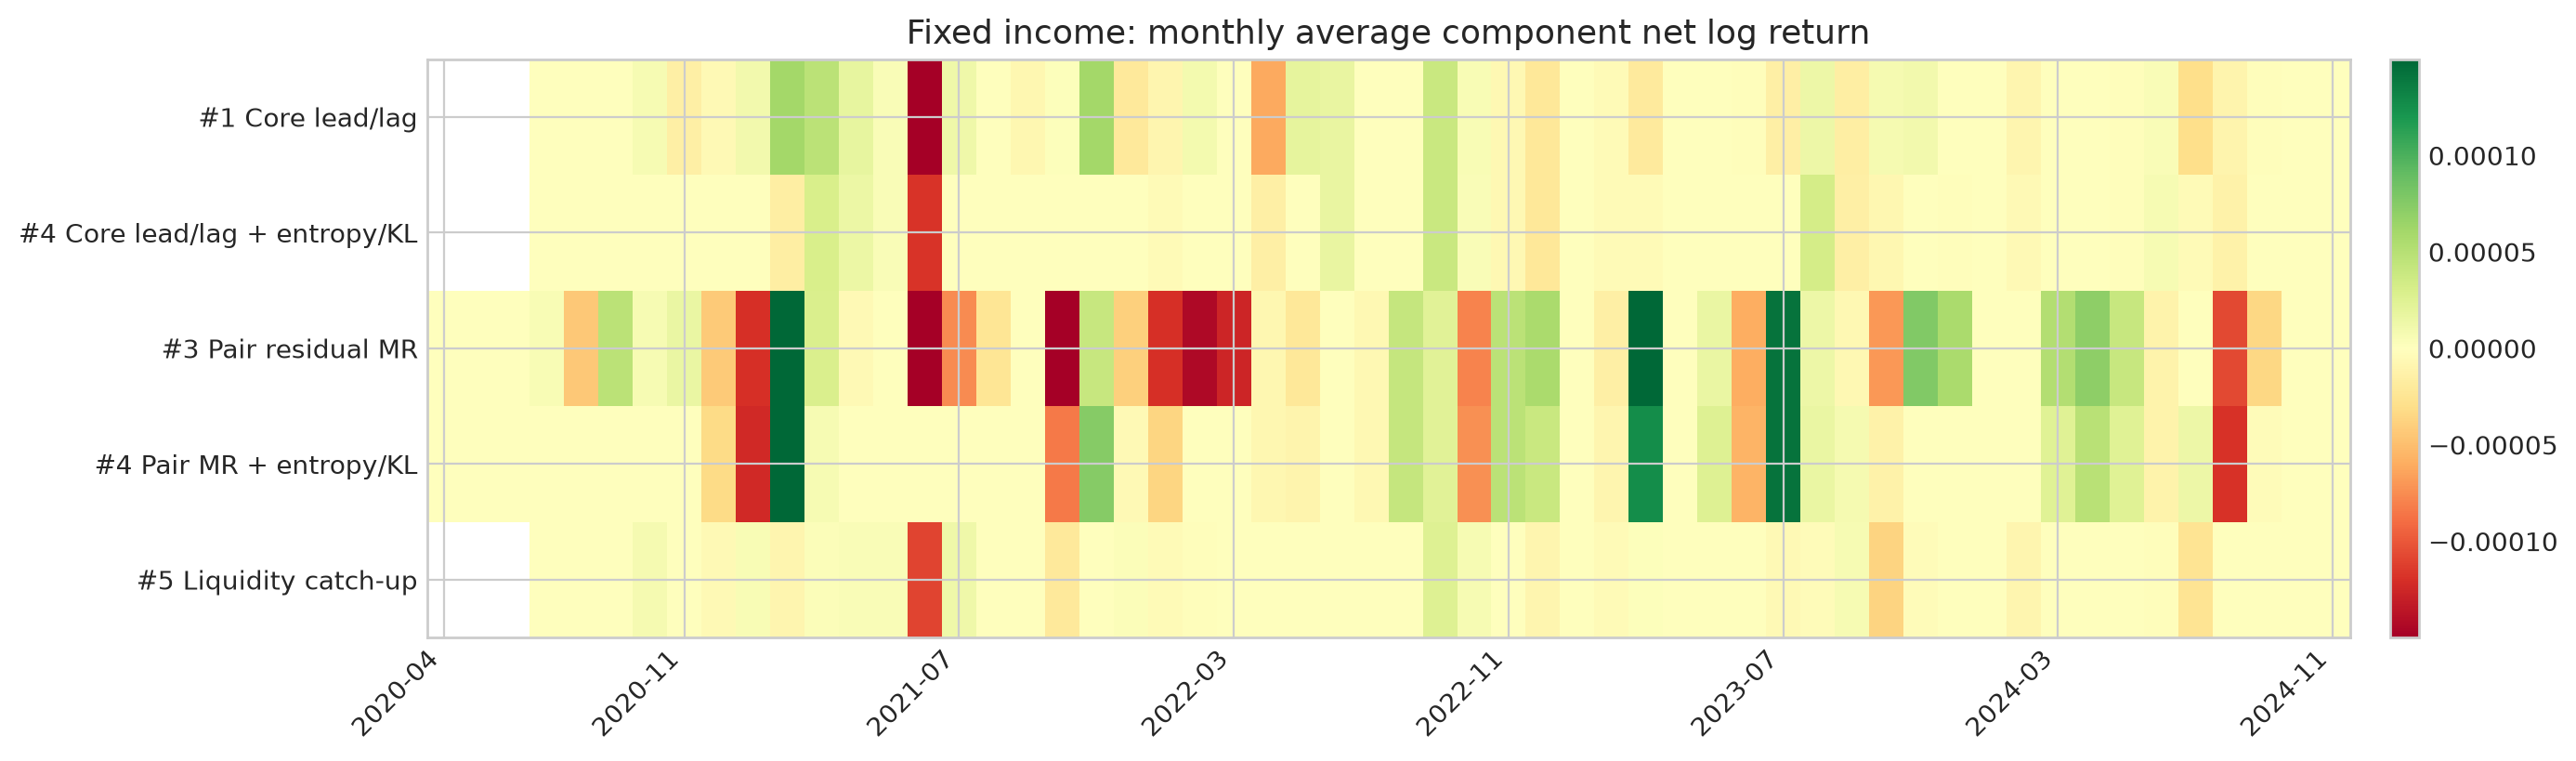

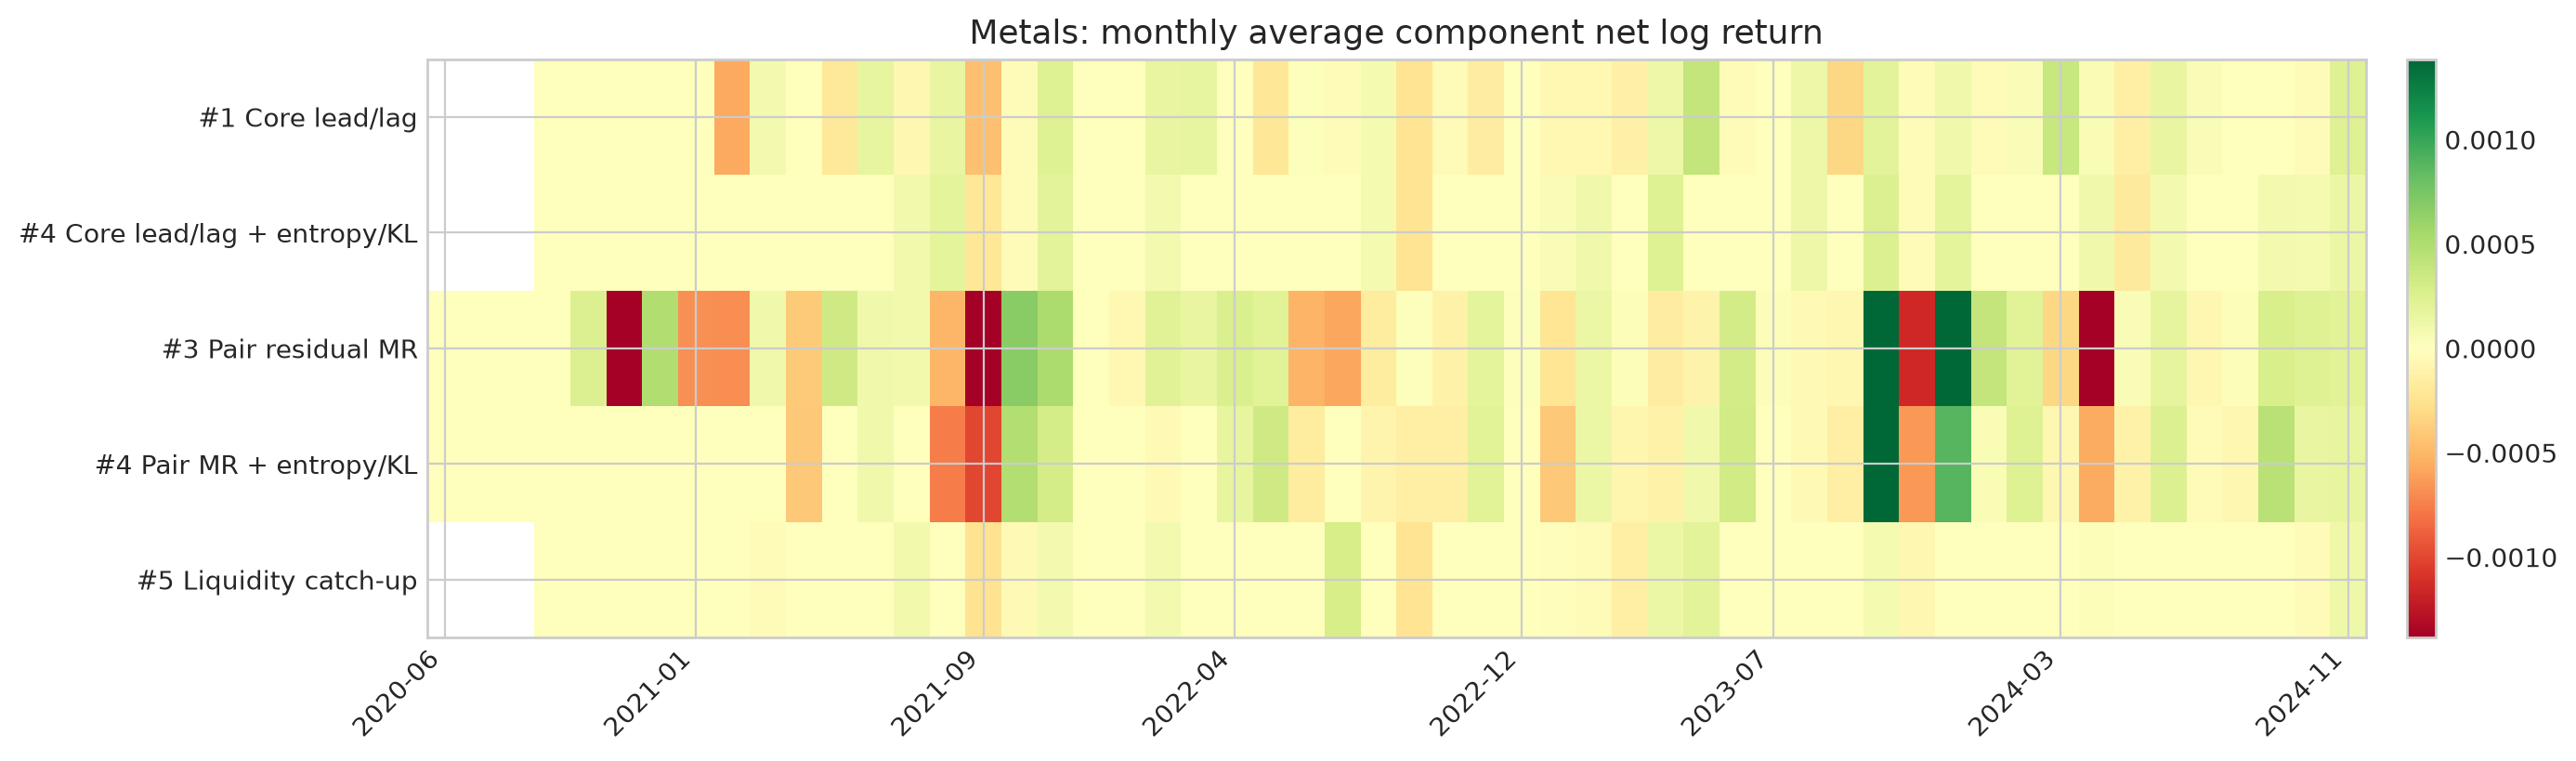

In [5]:
top_components = component_metrics.sort_values("annualized_sharpe", ascending=False)[
    [
        "group",
        "strategy_label",
        "component",
        "net_log_return",
        "annualized_sharpe",
        "max_drawdown_log",
        "active_fraction",
        "total_turnover",
    ]
].head(30)
display(top_components.round(4))

for group in ["Fixed income", "Metals"]:
    group_components = component_metrics.loc[component_metrics["group"] == group].copy()
    group_components["label"] = (
        group_components["strategy_label"] + " | " + group_components["component"]
    )
    group_components = group_components.sort_values("annualized_sharpe", ascending=False).head(25)
    fig, axis = plt.subplots(figsize=(9, max(5, 0.3 * len(group_components))))
    values = group_components[["annualized_sharpe"]].to_numpy(dtype=float)
    limit = np.nanmax(np.abs(values))
    image = axis.imshow(
        values,
        aspect="auto",
        cmap="RdYlGn",
        norm=TwoSlopeNorm(vcenter=0.0, vmin=-limit, vmax=limit),
    )
    axis.set_yticks(range(len(group_components)))
    axis.set_yticklabels(group_components["label"], fontsize=8)
    axis.set_xticks([0])
    axis.set_xticklabels(["Sharpe"])
    axis.set_title(f"{group}: top component Sharpe")
    for row, value in enumerate(values[:, 0]):
        axis.text(0, row, f"{value:.3f}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=axis, fraction=0.08, pad=0.03)
    fig.tight_layout()
    plt.show()

monthly = (
    component_returns.assign(month=lambda frame: frame.index.to_period("M").astype(str))
    .groupby(["group", "strategy", "month"], as_index=False)["net_return"]
    .mean()
)
for group in [group for group in GROUP_ORDER if group != "Energy"]:
    matrix = (
        monthly.loc[monthly["group"] == group]
        .pivot(index="strategy", columns="month", values="net_return")
        .reindex(STRATEGY_ORDER)
    )
    fig, axis = plt.subplots(figsize=(14, 4.2))
    values = matrix.to_numpy(dtype=float)
    limit = np.nanquantile(np.abs(values), 0.98)
    image = axis.imshow(
        values,
        aspect="auto",
        interpolation="nearest",
        cmap="RdYlGn",
        norm=TwoSlopeNorm(vcenter=0.0, vmin=-limit, vmax=limit),
    )
    axis.set_yticks(range(len(STRATEGY_ORDER)))
    axis.set_yticklabels([STRATEGY_LABELS[strategy] for strategy in STRATEGY_ORDER])
    locs = np.linspace(0, matrix.shape[1] - 1, min(8, matrix.shape[1]), dtype=int)
    axis.set_xticks(locs)
    axis.set_xticklabels(matrix.columns[locs], rotation=45, ha="right")
    axis.set_title(f"{group}: monthly average component net log return")
    fig.colorbar(image, ax=axis, fraction=0.025, pad=0.02)
    fig.tight_layout()
    plt.show()

## Initial Read

These are group-isolated daily-bar screens. They should not be compared directly to the 1-minute metals-only tests without accounting for granularity, execution assumptions, and the different sample end date.